<a href="https://colab.research.google.com/github/d-vf/Vector_Assembly_D-LI/blob/main/DLI_Gen_14032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set up

In [ ]:
! apt-get install -y graphviz libgraphviz-dev #data viz
! pip install pygraphviz diagrams # diagrams
! pip install pandapower==3.1.2
! pip install scipy #transform .m to .pp, kron product,linv
! pip install plotly==6.1.1 #cute plots
! pip install -U Kaleido==1.0.0 #to save pdf IO
! pip install numpy #scikit-learn scikit-optimize optuna hyperopt # parameter tuning
! apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 1 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http:/

In [ ]:
#Chrome driver is needed for kaleido
# Fetch a headless Chrome build just for this runtime
import kaleido
kaleido.get_chrome_sync()
# Restart the runtime (Runtime > Restart) so Kaleido sees Chrome

PosixPath('/root/.local/share/choreographer/deps/chrome-linux64/chrome')

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/Var_Volt_Control")
if not os.path.exists("conference_cdc"):
    os.mkdir("conference_cdc")

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/Var_Volt_Control/conference_cdc")

# Exp. A

In [ ]:
# Exp. A
import numpy as np
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.io as pio


# CONFIG
SHOW_PLOTS = True
SAVE_PDF   = True            # requires kaleido for PDF export
SAVE_HTML  = True
RENDERER   = None            # e.g., "browser", "notebook", "svg"

# PLOT STYLE
FONT_FAMILY = "Times New Roman"
FONT_SIZE   = 13
LEGEND_SIZE = 11
TEMPLATE    = "plotly_white"
LINE_W      = 2.5
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

XBAR = "x\u0304"
SBAR = "s\u0304"
SIGMA = "\u03c3"

FONT_FAMILY = "DejaVu Serif"
XBAR  = "x̄"
SBAR  = "s̄"
SIGMA = "σ"


if RENDERER is not None:
    pio.renderers.default = RENDERER


def _style(fig: go.Figure, width: int = 700, height: int = 400) -> go.Figure:
    fig.update_layout(
        template=TEMPLATE,
        font=dict(family=FONT_FAMILY, size=FONT_SIZE),
        width=width,
        height=height,
        margin=dict(l=65, r=25, t=55, b=60),
    )
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    return fig


def _legend_bottom(fig: go.Figure) -> go.Figure:
    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.20,
            xanchor="center",
            x=0.5,
            font=dict(size=LEGEND_SIZE),
            bgcolor="rgba(255,255,255,0)",
            borderwidth=0,
        ),
        margin=dict(b=95),
    )
    return fig


def _save(fig: go.Figure, stem: str) -> None:
    if SAVE_PDF:
        try:
            pio.write_image(fig, f"{stem}.pdf", format="pdf")
            print(f"[save] {stem}.pdf", end="  ")
        except Exception as e:
            print(f"[warn] PDF export skipped ({e})", end="  ")
    if SAVE_HTML:
        fig.write_html(f"{stem}.html", include_plotlyjs="cdn")
        print(f"[save] {stem}.html", end="")
    print()
    if SHOW_PLOTS:
        fig.show()


# CONSTRAINT AND OBJECTIVE HELPERS
def c_value(D: float, P: np.ndarray, u: np.ndarray) -> float:
    return float(D - np.asarray(P, float) @ np.asarray(u, float))


def c_plus(D: float, P: np.ndarray, u: np.ndarray) -> float:
    return max(0.0, c_value(D, P, u))


def integrality_gap(x: np.ndarray) -> float:
    x = np.asarray(x, float)
    return float(np.sum(x * (1.0 - x)))


COSTS    = np.array([1.0, 2.0, 6.0, 12.0], float)
LAMBDA_C = 50.0


def global_objective(u: np.ndarray, D: float, P: np.ndarray) -> float:
    u = np.asarray(u, float)
    return float(np.dot(COSTS, u) + LAMBDA_C * c_plus(D, P, u) ** 2)


# NETWORK SETUP
N_BUS              = 12
PHYS_EDGES         = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CONTROLLABLE_BUSES = [3, 6, 9, 12]
M                  = len(CONTROLLABLE_BUSES)
ITERATIONS         = 80
DEMAND_D           = 3.0
CAPACITY           = np.ones(M, float)
INNER_STEPS        = 25
SEED               = 2

np.random.seed(SEED)
assert len(COSTS) == M
EPS = np.finfo(float).eps

# Physical feeder graph
G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)
pos_phys = nx.spring_layout(G_phys, seed=SEED)

# Agent communication graph
HOP_THRESHOLD = 4
G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, bus_a in enumerate(CONTROLLABLE_BUSES):
    for b, bus_b in enumerate(CONTROLLABLE_BUSES):
        if b <= a:
            continue
        if nx.shortest_path_length(G_phys, bus_a, bus_b) <= HOP_THRESHOLD:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError("Comm graph disconnected — increase HOP_THRESHOLD.")

# Laplacian diffusion weights: W = I - alpha * L
L_c = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
dmax = int(max(dict(G_comm.degree()).values()))

alpha = 0.249  # valid here: alpha < 1/lam_max (=0.25) and alpha <= 1/dmax (=1/3)
W = np.eye(M) - alpha * L_c

assert np.allclose(W, W.T, atol=1e-12)
assert np.max(np.abs(W.sum(1) - 1)) < 1e-10
assert np.min(W) >= -1e-12

agent_labels = [f"Agent {i+1} (bus {CONTROLLABLE_BUSES[i]})" for i in range(M)]
short_labels = [f"A{i+1}/b{CONTROLLABLE_BUSES[i]}" for i in range(M)]


# D+LI STEP
# S^{+} = W S + diag(u - diag(S))

def dli_step(S: np.ndarray, u: np.ndarray, W_: np.ndarray) -> np.ndarray:
    """
    One inner round of Selector-Anchored D+LI (eq. 3 in paper).

    The update is:
        s_i^{t+1} = (W s^t)_i + E_i(u_i - E_i^T s_i^t)

    In the square-matrix encoding S[i,j] = agent i's estimate of u_j,
    E_i selects the diagonal entry S[i,i], so the innovation term becomes
        S_new[i,i] += u[i] - S_old[i,i]
    We snapshot diag(S) BEFORE mixing so the innovation is anchored at
    s^t (not the post-mix state), which matches the simultaneous update
    in eq. (3). For off-diagonal entries the two orderings agree because
    E_i does not act on j != i.
    """
    diag_old = np.diag(S).copy()          # snapshot at s^{k,t}
    S_new    = W_ @ S                     # diffusion
    idx      = np.arange(S.shape[0])
    S_new[idx, idx] += np.asarray(u, float) - diag_old   # innovation
    return S_new


# STACKED NORMS
def stacked_err(S: np.ndarray, u: np.ndarray) -> float:
    return float(np.linalg.norm((S - u[None, :]).ravel(order="C")))


def stacked_disagreement(S: np.ndarray) -> float:
    return float(np.linalg.norm((S - S.mean(0)).ravel(order="C")))


# LOCAL REPAIR RULE

def local_repair_action_simul(i: int, u_hat: np.ndarray,
                              D: float, P: np.ndarray) -> int:
    """
    Simultaneous decentralized repair rule.

    Agent i activates if, according to its local thresholded proxy u_hat,
    the demand shortfall requires K additional unit-capacity activations
    and i is among the K cheapest currently-off agents.

    Assumes unit capacities P_j = 1, as in Experiment A.
    """
    u_hat = np.asarray(u_hat, int)
    ui = int(u_hat[i])

    # If already on, stay on
    if ui == 1:
        return 1

    shortfall = c_plus(D, P, u_hat.astype(float))
    if shortfall <= 0.0:
        return 0

    # With unit capacities, K extra activations are needed
    K = int(np.ceil(shortfall))

    off_agents = [j for j in range(len(u_hat)) if u_hat[j] == 0]
    ranked_off = sorted(off_agents, key=lambda j: (COSTS[j], j))
    selected = set(ranked_off[:K])

    return 1 if i in selected else 0

# EXPERIMENT 1 — NAIVE AVERAGING BASELINE
x = np.array([1.0, 0.7, 0.1, 0.088], float)
mean_field_limit = float(np.mean(x))

H_mix      = np.zeros((ITERATIONS, M), float)
mix_cplus  = np.zeros(ITERATIONS, float)
mix_intgap = np.zeros(ITERATIONS, float)

for k in range(ITERATIONS):
    H_mix[k]      = x.copy()
    mix_cplus[k]  = max(c_plus(DEMAND_D, CAPACITY, x), EPS)
    mix_intgap[k] = max(integrality_gap(x), EPS)
    x = W @ x

# EXPERIMENT 2 — SELECTOR-ANCHORED D+LI + LOCAL REPAIR
u_loc = np.zeros(M, int)
S     = 0.2 * np.random.rand(M, M)   # keep nontrivial init for visible inner transients
S = np.zeros((M, M))

H_u         = np.zeros((ITERATIONS, M), float)
Jk          = np.zeros(ITERATIONS, float)
rk_c        = np.zeros(ITERATIONS, float)
inner_assem = np.zeros((ITERATIONS, INNER_STEPS + 1), float)
inner_cons  = np.zeros((ITERATIONS, INNER_STEPS + 1), float)

for k in range(ITERATIONS):
    u_glob  = u_loc.astype(float)
    H_u[k]  = u_glob.copy()
    Jk[k]   = global_objective(u_loc, DEMAND_D, CAPACITY)
    rk_c[k] = max(c_plus(DEMAND_D, CAPACITY, u_glob), EPS)

    inner_assem[k, 0] = max(stacked_err(S, u_glob), EPS)
    inner_cons[k, 0]  = max(stacked_disagreement(S), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        inner_assem[k, t + 1] = max(stacked_err(S, u_glob), EPS)
        inner_cons[k, t + 1]  = max(stacked_disagreement(S), EPS)


    # ── Outer repair step ────────────────────────────────────────────────────

    # ── Simultaneous decentralized outer repair step ───────────────────────
    u_next = u_loc.copy()

    for i_upd in range(M):
        u_hat = (S[i_upd] >= 0.5).astype(int)
        u_hat[i_upd] = int(u_loc[i_upd])   # exact owned coordinate

        u_next[i_upd] = local_repair_action_simul(
            i_upd, u_hat, DEMAND_D, CAPACITY
        )

    u_loc = u_next


print("Unique D+LI states:", np.unique(H_u, axis=0))
print("Agent trajectories identical?")
for i in range(M):
    for j in range(i+1, M):
        print(i, j, np.all(H_u[:, i] == H_u[:, j]))


# ISS VALIDATION — dominant |eig| direction of A_sys
u_fixed = np.array([1., 1., 1., 0.], float)
T_range = np.arange(1, INNER_STEPS + 1)

d = M
Pblk = np.zeros((d * d, d * d), float)
for i in range(d):
    Pblk[i * d + i, i * d + i] = 1.0

A = np.kron(W, np.eye(d)) - Pblk
evals, evecs = np.linalg.eigh(A)
idx = int(np.argmax(np.abs(evals)))
vmax = evecs[:, idx]
vmax = vmax / np.linalg.norm(vmax)

E0 = vmax.reshape(d, d, order="C")
S0_iss = u_fixed[None, :] + E0

S_iss  = S0_iss.copy()
n0_iss = float(np.linalg.norm((S_iss - u_fixed[None, :]).ravel(order="C")))
iss_norms = np.zeros(INNER_STEPS, float)

for t in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms[t] = float(np.linalg.norm((S_iss - u_fixed[None, :]).ravel(order="C")))


# SIGMA AND TRACKING BOUND

def _sigma(W_: np.ndarray) -> float:
    """
    Compute sigma = ||A_sys||_2 for the special case d_i = 1 for all i
    (i.e. each agent owns one scalar, so d = M = N and the stacked state
    lives in R^{M^2}).  In the general paper formulation d_i may differ;
    here the encoding S in R^{M x M} with S[i,i] = u_i corresponds to
    this scalar case.  A_sys = kron(W, I_M) - P_blk where P_blk has
    a 1 at position (i*M+i, i*M+i) for each i.
    """
    d    = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))

sigma      = _sigma(W)
pred_sigma = np.array([sigma ** t * n0_iss for t in range(1, INNER_STEPS + 1)])

# Include final post-update state in Delta_bar
U_aug = np.vstack([H_u, u_loc[None, :]])
#Delta_bar = np.sqrt(M)
Delta_bar = np.max(np.linalg.norm(np.diff(U_aug, axis=0), axis=1))
cor1_bound = (
    (np.sqrt(M) * sigma ** INNER_STEPS) / (1.0 - sigma ** INNER_STEPS) * Delta_bar
    if sigma ** INNER_STEPS < 1 else np.inf
)

U_aug = np.vstack([H_u, u_loc[None, :]])

Delta_bar_emp = float(
    np.max(np.linalg.norm(np.diff(U_aug, axis=0), axis=1))
)

# Global bound valid for every binary trajectory
Delta_bar_theory = np.sqrt(M)

tracking_bound_theory = (
    np.sqrt(M)
    * sigma ** INNER_STEPS
    / (1.0 - sigma ** INNER_STEPS)
    * Delta_bar_theory
)

tracking_value_emp = (
    np.sqrt(M)
    * sigma ** INNER_STEPS
    / (1.0 - sigma ** INNER_STEPS)
    * Delta_bar_emp
)


# SUPPLEMENTARY — EXTRA / DIGing on shared-x (not in paper)
# Included to illustrate that gradient-tracking methods solve
# a *different* problem (shared x, not identity-resolved u)
# and are not directly comparable to D+LI.
AUX_DIM   = 6
AUX_ITERS = 250


def make_quadratic(M, p, seed=7, mu=0.5):
    rng = np.random.default_rng(seed)
    Qs, bs = [], []
    for _ in range(M):
        A = rng.standard_normal((p, p))
        Qs.append(A.T @ A + mu * np.eye(p))
        bs.append(rng.standard_normal(p))
    return Qs, bs


def f_global(x, Qs, bs):
    return sum(0.5 * x @ (Q @ x) + b @ x for Q, b in zip(Qs, bs))


def solve_xstar(Qs, bs):
    return -np.linalg.solve(np.sum(Qs, axis=0), np.sum(bs, axis=0))


def run_EXTRA_shared(W, Qs, bs, iters, eta, seed=11):
    rng = np.random.default_rng(seed)
    M, p = W.shape[0], Qs[0].shape[0]
    Wt   = 0.5 * (np.eye(M) + W)

    X0 = rng.standard_normal((M, p))
    G0 = np.vstack([Qs[i] @ X0[i] + bs[i] for i in range(M)])

    X1 = W @ X0 - eta * G0
    G1 = np.vstack([Qs[i] @ X1[i] + bs[i] for i in range(M)])

    Xp, Xc, Gp, Gc = X0, X1, G0, G1
    hist = np.zeros((iters, p))

    for k in range(iters):
        hist[k] = Xc.mean(0)
        Xn = Xc + W @ Xc - Wt @ Xp - eta * (Gc - Gp)
        Gn = np.vstack([Qs[i] @ Xn[i] + bs[i] for i in range(M)])
        Xp, Xc, Gp, Gc = Xc, Xn, Gc, Gn

    return hist


def run_DIGing_shared(W, Qs, bs, iters, eta, seed=13):
    rng = np.random.default_rng(seed)
    M, p = W.shape[0], Qs[0].shape[0]

    Xk = rng.standard_normal((M, p))
    Gk = np.vstack([Qs[i] @ Xk[i] + bs[i] for i in range(M)])
    Yk = Gk.copy()
    hist = np.zeros((iters, p))

    for k in range(iters):
        hist[k] = Xk.mean(0)
        Xn = W @ Xk - eta * Yk
        Gn = np.vstack([Qs[i] @ Xn[i] + bs[i] for i in range(M)])
        Yn = W @ Yk + (Gn - Gk)
        Xk, Gk, Yk = Xn, Gn, Yn

    return hist


Qs, bs   = make_quadratic(M, AUX_DIM)
xstar    = solve_xstar(Qs, bs)
fstar    = f_global(xstar, Qs, bs)
Lmax     = max(float(np.linalg.eigvalsh(Q).max()) for Q in Qs)
eta_aux  = 0.35 / Lmax

hist_ext = run_EXTRA_shared(W, Qs, bs, AUX_ITERS, eta_aux)
hist_dig = run_DIGing_shared(W, Qs, bs, AUX_ITERS, eta_aux)

gap_extra = np.array([max(f_global(x_, Qs, bs) - fstar, EPS) for x_ in hist_ext])
gap_dig   = np.array([max(f_global(x_, Qs, bs) - fstar, EPS) for x_ in hist_dig])


# EXPORT .dat FOR PGFPLOTS
df_mix = pd.DataFrame({"Iter": np.arange(ITERATIONS)})
df_dli = pd.DataFrame({"Iter": np.arange(ITERATIONS)})

for i in range(M):
    df_mix[f"x{i+1}"] = H_mix[:, i]
    df_dli[f"u{i+1}"] = H_u[:, i]

df_mix.to_csv("data_baseline_mixing.dat", sep="\t", index=False, header=True)
df_dli.to_csv("data_dli.dat", sep="\t", index=False, header=True)

pd.DataFrame({
    "T": T_range,
    "ratio": iss_norms / n0_iss,
    "bound": pred_sigma / n0_iss,
}).to_csv("data_iss_validation.dat", sep="\t", index=False)

pd.DataFrame({
    "k": np.arange(ITERATIONS),
    "e_kT": inner_assem[:, -1],
    "bound": np.full(ITERATIONS, cor1_bound),
}).to_csv("data_corollary1.dat", sep="\t", index=False)

print("[save] .dat files written")

# FIGURES
def fig_physical_network(stem="fig_phys_network"):
    ctrl     = set(CONTROLLABLE_BUSES)
    non_ctrl = [n for n in G_phys.nodes() if n not in ctrl]

    ex, ey = [], []
    for u, v in G_phys.edges():
        x0, y0 = pos_phys[u]
        x1, y1 = pos_phys[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    def ntrace(nodes, sym, color, name):
        return go.Scatter(
            x=[pos_phys[n][0] for n in nodes],
            y=[pos_phys[n][1] for n in nodes],
            mode="markers+text",
            text=[str(n) for n in nodes],
            textposition="middle center",
            textfont=dict(size=10, color="white"),
            marker=dict(size=24, symbol=sym, color=color,
                        line=dict(width=1.5, color="#333")),
            name=name
        )

    fig = go.Figure([
        go.Scatter(
            x=ex, y=ey, mode="lines",
            line=dict(width=1.8, color="#888"),
            hoverinfo="none", showlegend=False
        ),
        ntrace(non_ctrl, "circle", "#aec7e8", "Non-controllable bus"),
        ntrace(list(ctrl), "square", "#1f77b4", "Controllable bus (agent)"),
    ])


    fig.update_layout(
        title=dict(text="Physical feeder topology", x=0.5),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        legend=dict(
            orientation="h",
            y=-0.18,
            x=0.5,
            xanchor="center",
            font=dict(size=LEGEND_SIZE)
        ),
        margin=dict(l=65, r=25, t=55, b=85),
    )

    _style(fig, width=520, height=420)
    _save(fig, stem)



def fig_comm_graph(stem="fig_comm_graph"):
    # place each agent at the position of its physical controllable bus
    pos = {i: pos_phys[CONTROLLABLE_BUSES[i]] for i in range(M)}

    fig = go.Figure()

    # faint physical feeder in the background for context
    ex_bg, ey_bg = [], []
    for u, v in G_phys.edges():
        x0, y0 = pos_phys[u]
        x1, y1 = pos_phys[v]
        ex_bg += [x0, x1, None]
        ey_bg += [y0, y1, None]

    fig.add_trace(go.Scatter(
        x=ex_bg, y=ey_bg, mode="lines",
        line=dict(width=1.1, color="rgba(160,160,160,0.45)"),
        hoverinfo="none",
        showlegend=False
    ))

    # optionally show all physical buses faintly
    fig.add_trace(go.Scatter(
        x=[pos_phys[n][0] for n in G_phys.nodes()],
        y=[pos_phys[n][1] for n in G_phys.nodes()],
        mode="markers",
        marker=dict(
            size=10,
            color="rgba(180,180,180,0.55)",
            line=dict(width=0.8, color="rgba(120,120,120,0.6)")
        ),
        hoverinfo="skip",
        showlegend=False
    ))

    # communication edges between controllable agents
    ex, ey = [], []
    for i, j in G_comm.edges():
        x0, y0 = pos[i]
        x1, y1 = pos[j]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    fig.add_trace(go.Scatter(
        x=ex, y=ey, mode="lines",
        line=dict(width=2.8, color="#444"),
        hoverinfo="none",
        name="Communication edge",
        showlegend=False
    ))

    # controllable-agent nodes on top
    fig.add_trace(go.Scatter(
        x=[pos[i][0] for i in range(M)],
        y=[pos[i][1] for i in range(M)],
        mode="markers+text",
        text=[f"A{i+1}<br>b{CONTROLLABLE_BUSES[i]}" for i in range(M)],
        textposition="top center",
        textfont=dict(size=11),
        marker=dict(
            size=24,
            symbol="square",
            color="#1f77b4",
            line=dict(width=1.6, color="#333")
        ),
        name="Controllable agent",
        showlegend=False
    ))

    fig.update_layout(
        title=dict(
            text=f"Communication graph induced by feeder hop distance (h = {HOP_THRESHOLD})",
            x=0.5
        ),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
    )

    _style(fig, width=520, height=400)
    _save(fig, stem)


def fig_trajectories(stem="fig_traj_compare"):
    iters = np.arange(ITERATIONS)

    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.13,
        subplot_titles=(
            "Baseline: naive consensus averaging",
            "Proposed D+LI with simultaneous local repair"
        )
    )

    for i in range(M):
        fig.add_trace(go.Scatter(
            x=iters, y=H_mix[:, i], mode="lines",
            line=dict(width=LINE_W, color=COLORS[i]),
            name=short_labels[i]
        ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=iters, y=mean_field_limit * np.ones(ITERATIONS),
        mode="lines",
        line=dict(width=1.5, color="black", dash="dash"),
        name=f"mean = {mean_field_limit:.3f}"
    ), row=1, col=1)

    for i in range(M):
        fig.add_trace(go.Scatter(
            x=iters, y=H_u[:, i], mode="lines",
            line=dict(width=LINE_W, color=COLORS[i], shape="hv"),
            showlegend=False
        ), row=1, col=2)

    fig.update_xaxes(title_text="Outer iteration k", row=1, col=1)
    fig.update_xaxes(title_text="Outer iteration k", row=1, col=2)
    fig.update_yaxes(title_text="x<sub>i</sub>", range=[-0.05, 1.05], row=1, col=1)
    fig.update_yaxes(title_text="u<sub>i</sub>", range=[-0.2, 1.2], tickvals=[0, 1], row=1, col=2)

    _style(fig, width=820, height=380)
    _legend_bottom(fig)
    _save(fig, stem)


def fig_outer_diagnostics(stem="fig_outer_diagnostics"):
    iters = np.arange(ITERATIONS)

    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.15,
        subplot_titles=(
            "Objective J(u<sup>k</sup>)",
            "Demand residual c<sub>+</sub>(u<sup>k</sup>)"
        )
    )

    fig.add_trace(go.Scatter(
        x=iters, y=Jk, mode="lines",
        line=dict(width=LINE_W, color=COLORS[0]),
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=iters, y=rk_c, mode="lines",
        line=dict(width=LINE_W, color=COLORS[1]),
        showlegend=False
    ), row=1, col=2)

    fig.update_xaxes(title_text="Outer iteration k", row=1, col=1)
    fig.update_xaxes(title_text="Outer iteration k", row=1, col=2)
    fig.update_yaxes(title_text="J(u<sup>k</sup>)", row=1, col=1)
    fig.update_yaxes(title_text="c<sub>+</sub>(u<sup>k</sup>)", type="log", row=1, col=2)

    _style(fig, width=760, height=360)
    _save(fig, stem)


def fig_inner_traces(ks=(0, 1, 2), stem="fig_inner_diffusion"):
    ts = np.arange(INNER_STEPS + 1)

    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.15,
        subplot_titles=(
            "Assembly residual ||S<sup>k,t</sup> - 1(u<sup>k</sup>)<sup>T</sup>||<sub>F</sub>",
            f"Estimator dispersion ||S<sup>k,t</sup> - 1({SBAR}<sup>k,t</sup>)<sup>T</sup>||<sub>F</sub>"
        )
    )


    dashes = ["solid", "dash", "dot", "dashdot"]

    for idx, k in enumerate(ks):
        kk = (ITERATIONS + k) if k < 0 else k

        fig.add_trace(go.Scatter(
            x=ts, y=inner_assem[kk], mode="lines",
            line=dict(width=LINE_W,
                      color=COLORS[idx % len(COLORS)],
                      dash=dashes[idx % len(dashes)]),
            name=f"k = {kk}"
        ), row=1, col=1)

        fig.add_trace(go.Scatter(
            x=ts, y=inner_cons[kk], mode="lines",
            line=dict(width=LINE_W,
                      color=COLORS[idx % len(COLORS)],
                      dash=dashes[idx % len(dashes)]),
            name=f"k = {kk}",
            showlegend=False
        ), row=1, col=2)

    for col in [1, 2]:
        fig.update_xaxes(title_text="Inner round t", row=1, col=col)
        fig.update_yaxes(title_text="Residual magnitude (log scale)", type="log", row=1, col=col)

    _style(fig, width=820, height=380)
    _legend_bottom(fig)
    _save(fig, stem)


def fig_assembly_compare(stem="fig_assembly_compare"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig = go.Figure([
        go.Scatter(
            x=T_range, y=ratio, mode="lines+markers",
            line=dict(width=LINE_W, color=COLORS[0]),
            marker=dict(size=5),
            name="D+LI empirical ||e<sup>T</sup>|| / ||e<sup>0</sup>||"
        ),
        go.Scatter(
            x=T_range, y=bound, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name=f"Bound {SIGMA}<sup>T</sup>"
        ),
    ])

    fig.update_xaxes(title_text="Inner rounds T")
    fig.update_yaxes(
        title_text="||e<sup>T</sup>|| / ||e<sup>0</sup>|| (log scale)",
        type="log"
    )
    fig.update_layout(
        title=dict(
            text=f"Estimator contraction validation ({SIGMA} = {sigma:.4f})",
            x=0.5
        )
    )

    _style(fig, width=600, height=400)
    _legend_bottom(fig)
    _save(fig, stem)


def fig_corollary1(stem="fig_corollary1"):
    k_vals = np.arange(ITERATIONS)

    fig = go.Figure([
        go.Scatter(
            x=k_vals, y=inner_assem[:, -1], mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="Empirical ||e<sup>k,T</sup>||"
        ),
        go.Scatter(
            x=k_vals, y=np.full(ITERATIONS, cor1_bound), mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name=f"Bound = {cor1_bound:.4g}"
        ),
    ])

    fig.update_xaxes(title_text="Outer iteration k")
    fig.update_yaxes(title_text="||e<sup>k,T</sup>|| (log scale)", type="log")
    fig.update_layout(
        title=dict(
            text="Finite-horizon estimator tracking bound (stacked norm)",
            x=0.5
        )
    )
    _style(fig, width=600, height=400)
    _legend_bottom(fig)
    _save(fig, stem)


def fig_shared_x_benchmark(stem="fig_shared_x_benchmark"):
    it = np.arange(AUX_ITERS)

    fig = go.Figure([
        go.Scatter(
            x=it, y=gap_extra, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="EXTRA"
        ),
        go.Scatter(
            x=it, y=gap_dig, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name="DIGing"
        ),
    ])

    fig.update_xaxes(title_text="Iterations")
    fig.update_yaxes(title_text=f"F({XBAR}<sup>k</sup>) - F(x*) (log scale)", type="log")
    fig.update_layout(
        title=dict(
            text="EXTRA / DIGing on shared-x consensus (native problem class)",
            x=0.5
        )
    )
    _style(fig, width=600, height=400)
    _legend_bottom(fig)
    _save(fig, stem)

# RUN ALL FIGURES
fig_physical_network()
fig_comm_graph()
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary1()
fig_shared_x_benchmark()


# SANITY PRINTS
u_final = u_loc.copy()
x_final = x.copy()

print("\n--- Baseline (naive averaging) final ---")
print(f"  x={np.round(x_final, 3)}  mean={x_final.mean():.3f}  "
      f"(frozen at mean(x0)={mean_field_limit:.3f})")
print(f"  c+(x)={c_plus(DEMAND_D, CAPACITY, x_final):.3e}  "
      f"integrality gap={integrality_gap(x_final):.3e}")

print("\n--- D+LI final ---")
print(f"  u={u_final}  sum(P*u)={float(CAPACITY @ u_final):.1f}")
print(f"  c+(u)={c_plus(DEMAND_D, CAPACITY, u_final):.3e}")
print(f"  J(u)={global_objective(u_final, DEMAND_D, CAPACITY):.3f}")

print("\n--- ISS validation (D+LI inner loop) ---")
print(f"  sigma={sigma:.6f}  (comm graph, {G_comm.number_of_edges()} edges)")
print(f"  n0_iss={n0_iss:.4f}  (initial stacked error)")
print(f"  T=1:  empirical={iss_norms[0] / n0_iss:.3e}  bound={sigma**1:.3e}")
print(f"  T=5:  empirical={iss_norms[4] / n0_iss:.3e}  bound={sigma**5:.3e}")
print(f"  T={INNER_STEPS}: empirical={iss_norms[-1] / n0_iss:.3e}  "
      f"bound={sigma**INNER_STEPS:.3e}")

print("\n--- Corollary bound inputs ---")
print(f"  Delta_bar={Delta_bar:.4f}  bound={cor1_bound:.6g}")

print("\n--- Graph / weight checks ---")
print(f"  Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
      f"connected={nx.is_connected(G_comm)}, HOP_THRESHOLD={HOP_THRESHOLD}")
print(f"  W symmetric={np.allclose(W, W.T)}  "
      f"row-sum err={np.max(np.abs(W.sum(1) - 1)):.1e}  "
      f"col-sum err={np.max(np.abs(W.sum(0) - 1)):.1e}")

Unique D+LI states: [[0. 0. 0. 0.]
 [1. 1. 1. 0.]]
Agent trajectories identical?
0 1 True
0 2 True
0 3 False
1 2 True
1 3 False
2 3 False
[save] .dat files written
[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_phys_network.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_comm_graph.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_traj_compare.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_outer_diagnostics.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_inner_diffusion.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_assembly_compare.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_corollary1.html


[warn] PDF export skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_shared_x_benchmark.html



--- Baseline (naive averaging) final ---
  x=[0.472 0.472 0.472 0.472]  mean=0.472  (frozen at mean(x0)=0.472)
  c+(x)=1.112e+00  integrality gap=9.969e-01

--- D+LI final ---
  u=[1 1 1 0]  sum(P*u)=3.0
  c+(u)=0.000e+00
  J(u)=9.000

--- ISS validation (D+LI inner loop) ---
  sigma=0.901227  (comm graph, 5 edges)
  n0_iss=1.0000  (initial stacked error)
  T=1:  empirical=9.012e-01  bound=9.012e-01
  T=5:  empirical=5.945e-01  bound=5.945e-01
  T=25: empirical=7.428e-02  bound=7.428e-02

--- Corollary bound inputs ---
  Delta_bar=1.7321  bound=0.277949

--- Graph / weight checks ---
  Comm graph: 4 nodes, 5 edges, connected=True, HOP_THRESHOLD=4
  W symmetric=True  row-sum err=0.0e+00  col-sum err=0.0e+00


##Exp. A (matplotlib)

Unique D+LI states: [[0. 0. 0. 0.]
 [1. 1. 1. 0.]]
Agent trajectories identical?
0 1 True
0 2 True
0 3 False
1 2 True
1 3 False
2 3 False
[save] .dat files written
[save] fig_phys_network.pdf  [save] fig_phys_network.png


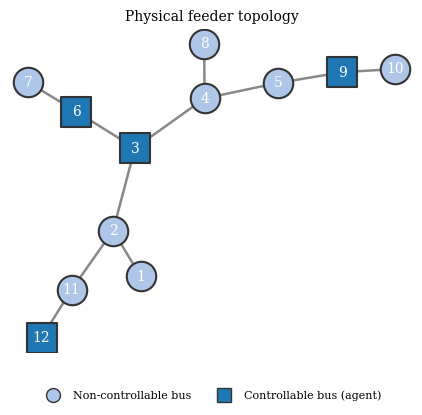

[save] fig_comm_graph.pdf  [save] fig_comm_graph.png


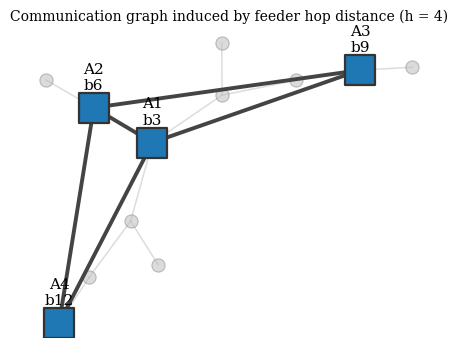

[save] fig_traj_compare.pdf  [save] fig_traj_compare.png


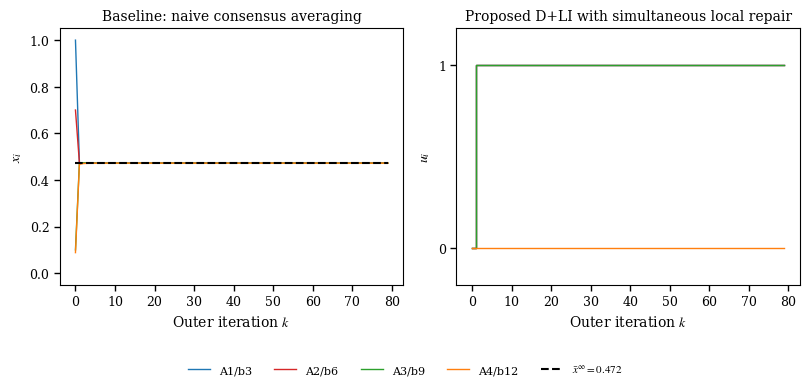

[save] fig_outer_diagnostics.pdf  [save] fig_outer_diagnostics.png


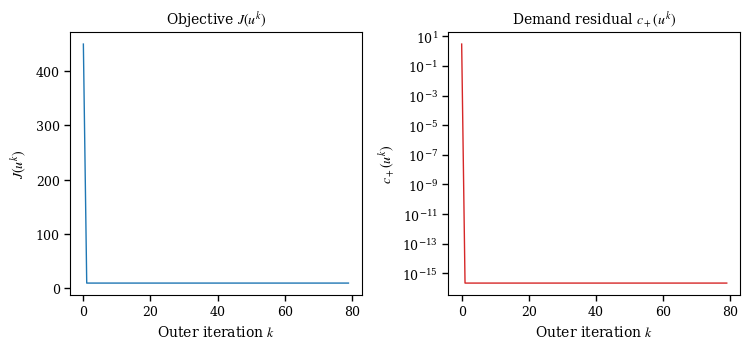

[save] fig_inner_diffusion.pdf  [save] fig_inner_diffusion.png


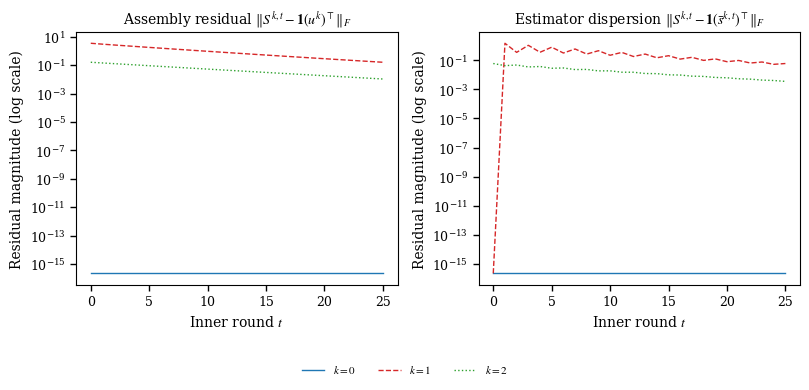

[save] fig_assembly_compare.pdf  [save] fig_assembly_compare.png


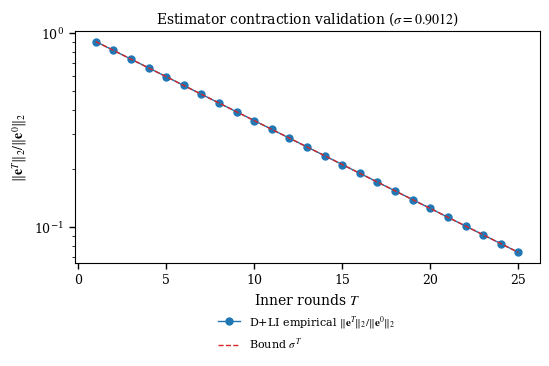

[save] fig_corollary1.pdf  [save] fig_corollary1.png


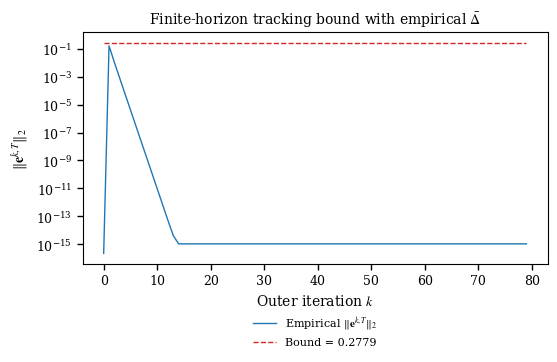

[save] fig_shared_x_benchmark.pdf  [save] fig_shared_x_benchmark.png


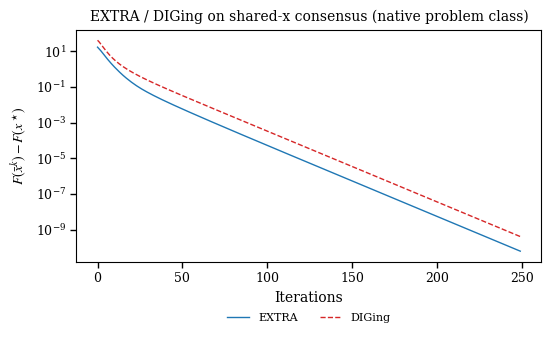


--- Baseline (naive averaging) final ---
  x=[0.472 0.472 0.472 0.472]  mean=0.472  (frozen at mean(x0)=0.472)
  c+(x)=1.112e+00  integrality gap=9.969e-01

--- D+LI final ---
  u=[1 1 1 0]  sum(P*u)=3.0
  c+(u)=0.000e+00
  J(u)=9.000

--- ISS validation (D+LI inner loop) ---
  sigma=0.901227  (comm graph, 5 edges)
  n0_iss=1.0000  (initial stacked error)
  T=1:  empirical=9.012e-01  bound=9.012e-01
  T=5:  empirical=5.945e-01  bound=5.945e-01
  T=25: empirical=7.428e-02  bound=7.428e-02

--- Corollary bound inputs ---
  Delta_bar=1.7321  bound=0.277949

--- Graph / weight checks ---
  Comm graph: 4 nodes, 5 edges, connected=True, HOP_THRESHOLD=4
  W symmetric=True  row-sum err=0.0e+00  col-sum err=0.0e+00


In [ ]:
# Exp. A (matplotlib)
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# CONFIG
SHOW_PLOTS = True
SAVE_PDF   = True
SAVE_PNG   = True

# PLOT STYLE
FONT_SIZE   = 10
LEGEND_SIZE = 8
LINE_W      = 1.0
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

XBAR  = r"\bar{x}"
SBAR  = r"\bar{s}"
DBAR  = r"\bar{\Delta}"
SIGMA = r"\sigma"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def _style_ax(ax):
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(direction="out", length=4, width=1)
    return ax


def _savefig(fig, stem):
    if SAVE_PDF:
        fig.savefig(f"{stem}.pdf", bbox_inches="tight", pad_inches=0.03)
        print(f"[save] {stem}.pdf", end="  ")
    if SAVE_PNG:
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
        print(f"[save] {stem}.png", end="")
    print()
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


# CONSTRAINT AND OBJECTIVE HELPERS

def c_value(D: float, P: np.ndarray, u: np.ndarray) -> float:
    return float(D - np.asarray(P, float) @ np.asarray(u, float))


def c_plus(D: float, P: np.ndarray, u: np.ndarray) -> float:
    return max(0.0, c_value(D, P, u))


def integrality_gap(x: np.ndarray) -> float:
    x = np.asarray(x, float)
    return float(np.sum(x * (1.0 - x)))


COSTS    = np.array([1.0, 2.0, 6.0, 12.0], float)
LAMBDA_C = 50.0


def global_objective(u: np.ndarray, D: float, P: np.ndarray) -> float:
    u = np.asarray(u, float)
    return float(np.dot(COSTS, u) + LAMBDA_C * c_plus(D, P, u) ** 2)

# NETWORK SETUP

N_BUS              = 12
PHYS_EDGES         = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CONTROLLABLE_BUSES = [3, 6, 9, 12]
M                  = len(CONTROLLABLE_BUSES)
ITERATIONS         = 80
DEMAND_D           = 3.0
CAPACITY           = np.ones(M, float)
INNER_STEPS        = 25
SEED               = 2

np.random.seed(SEED)
assert len(COSTS) == M
EPS = np.finfo(float).eps

# Physical feeder graph
G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)
pos_phys = nx.spring_layout(G_phys, seed=SEED)

# Agent communication graph
HOP_THRESHOLD = 4
G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, bus_a in enumerate(CONTROLLABLE_BUSES):
    for b, bus_b in enumerate(CONTROLLABLE_BUSES):
        if b <= a:
            continue
        if nx.shortest_path_length(G_phys, bus_a, bus_b) <= HOP_THRESHOLD:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError("Comm graph disconnected — increase HOP_THRESHOLD.")

# Laplacian diffusion weights: W = I - alpha * L
L_c = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
dmax = int(max(dict(G_comm.degree()).values()))

alpha = 0.249
W = np.eye(M) - alpha * L_c

assert np.allclose(W, W.T, atol=1e-12)
assert np.max(np.abs(W.sum(1) - 1)) < 1e-10
assert np.min(W) >= -1e-12

short_labels = [f"A{i+1}/b{CONTROLLABLE_BUSES[i]}" for i in range(M)]



# D+LI STEP
# S^{+} = W S + diag(u - diag(S))

def dli_step(S: np.ndarray, u: np.ndarray, W_: np.ndarray) -> np.ndarray:
    diag_old = np.diag(S).copy()
    S_new    = W_ @ S
    idx      = np.arange(S.shape[0])
    S_new[idx, idx] += np.asarray(u, float) - diag_old
    return S_new

# STACKED NORMS

def stacked_err(S: np.ndarray, u: np.ndarray) -> float:
    return float(np.linalg.norm((S - u[None, :]).ravel(order="C")))


def stacked_disagreement(S: np.ndarray) -> float:
    return float(np.linalg.norm((S - S.mean(0)).ravel(order="C")))


# LOCAL REPAIR RULE

def local_repair_action_simul(i: int, u_hat: np.ndarray,
                              D: float, P: np.ndarray) -> int:
    u_hat = np.asarray(u_hat, int)
    ui = int(u_hat[i])

    if ui == 1:
        return 1

    shortfall = c_plus(D, P, u_hat.astype(float))
    if shortfall <= 0.0:
        return 0

    K = int(np.ceil(shortfall))
    off_agents = [j for j in range(len(u_hat)) if u_hat[j] == 0]
    ranked_off = sorted(off_agents, key=lambda j: (COSTS[j], j))
    selected = set(ranked_off[:K])

    return 1 if i in selected else 0

# EXPERIMENT 1 — NAIVE AVERAGING BASELINE

x = np.array([1.0, 0.7, 0.1, 0.088], float)
mean_field_limit = float(np.mean(x))

H_mix      = np.zeros((ITERATIONS, M), float)
mix_cplus  = np.zeros(ITERATIONS, float)
mix_intgap = np.zeros(ITERATIONS, float)

for k in range(ITERATIONS):
    H_mix[k]      = x.copy()
    mix_cplus[k]  = max(c_plus(DEMAND_D, CAPACITY, x), EPS)
    mix_intgap[k] = max(integrality_gap(x), EPS)
    x = W @ x


# EXPERIMENT 2 — SELECTOR-ANCHORED D+LI + LOCAL REPAIR

u_loc = np.zeros(M, int)
S     = 0.2 * np.random.rand(M, M)
S = np.zeros((M, M))
H_u         = np.zeros((ITERATIONS, M), float)
Jk          = np.zeros(ITERATIONS, float)
rk_c        = np.zeros(ITERATIONS, float)
inner_assem = np.zeros((ITERATIONS, INNER_STEPS + 1), float)
inner_cons  = np.zeros((ITERATIONS, INNER_STEPS + 1), float)

for k in range(ITERATIONS):
    u_glob  = u_loc.astype(float)
    H_u[k]  = u_glob.copy()
    Jk[k]   = global_objective(u_loc, DEMAND_D, CAPACITY)
    rk_c[k] = max(c_plus(DEMAND_D, CAPACITY, u_glob), EPS)

    inner_assem[k, 0] = max(stacked_err(S, u_glob), EPS)
    inner_cons[k, 0]  = max(stacked_disagreement(S), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        inner_assem[k, t + 1] = max(stacked_err(S, u_glob), EPS)
        inner_cons[k, t + 1]  = max(stacked_disagreement(S), EPS)

    u_next = u_loc.copy()
    for i_upd in range(M):
        u_hat = (S[i_upd] >= 0.5).astype(int)
        u_hat[i_upd] = int(u_loc[i_upd])
        u_next[i_upd] = local_repair_action_simul(
            i_upd, u_hat, DEMAND_D, CAPACITY
        )
    u_loc = u_next


print("Unique D+LI states:", np.unique(H_u, axis=0))
print("Agent trajectories identical?")
for i in range(M):
    for j in range(i + 1, M):
        print(i, j, np.all(H_u[:, i] == H_u[:, j]))



# ISS VALIDATION — dominant |eig| direction of A_sys

u_fixed = np.array([1., 1., 1., 0.], float)
T_range = np.arange(1, INNER_STEPS + 1)

d = M
Pblk = np.zeros((d * d, d * d), float)
for i in range(d):
    Pblk[i * d + i, i * d + i] = 1.0

A = np.kron(W, np.eye(d)) - Pblk
evals, evecs = np.linalg.eigh(A)
idx = int(np.argmax(np.abs(evals)))
vmax = evecs[:, idx]
vmax = vmax / np.linalg.norm(vmax)

E0 = vmax.reshape(d, d, order="C")
S0_iss = u_fixed[None, :] + E0

S_iss  = S0_iss.copy()
n0_iss = float(np.linalg.norm((S_iss - u_fixed[None, :]).ravel(order="C")))
iss_norms = np.zeros(INNER_STEPS, float)

for t in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms[t] = float(np.linalg.norm((S_iss - u_fixed[None, :]).ravel(order="C")))



# SIGMA AND TRACKING BOUND

def _sigma(W_: np.ndarray) -> float:
    d    = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))


sigma      = _sigma(W)
pred_sigma = np.array([sigma ** t * n0_iss for t in range(1, INNER_STEPS + 1)])

U_aug = np.vstack([H_u, u_loc[None, :]])
Delta_bar = np.max(np.linalg.norm(np.diff(U_aug, axis=0), axis=1))
cor1_bound = (
    (np.sqrt(M) * sigma ** INNER_STEPS) / (1.0 - sigma ** INNER_STEPS) * Delta_bar
    if sigma ** INNER_STEPS < 1 else np.inf
)

U_aug = np.vstack([H_u, u_loc[None, :]])

Delta_bar_emp = float(
    np.max(np.linalg.norm(np.diff(U_aug, axis=0), axis=1))
)

# Global bound valid for every binary trajectory
Delta_bar_theory = np.sqrt(M)

tracking_bound_theory = (
    np.sqrt(M)
    * sigma ** INNER_STEPS
    / (1.0 - sigma ** INNER_STEPS)
    * Delta_bar_theory
)

tracking_value_emp = (
    np.sqrt(M)
    * sigma ** INNER_STEPS
    / (1.0 - sigma ** INNER_STEPS)
    * Delta_bar_emp
)


# SUPPLEMENTARY — EXTRA / DIGing on shared-x (not in paper)

AUX_DIM   = 6
AUX_ITERS = 250


def make_quadratic(M, p, seed=7, mu=0.5):
    rng = np.random.default_rng(seed)
    Qs, bs = [], []
    for _ in range(M):
        A = rng.standard_normal((p, p))
        Qs.append(A.T @ A + mu * np.eye(p))
        bs.append(rng.standard_normal(p))
    return Qs, bs


def f_global(x, Qs, bs):
    return sum(0.5 * x @ (Q @ x) + b @ x for Q, b in zip(Qs, bs))


def solve_xstar(Qs, bs):
    return -np.linalg.solve(np.sum(Qs, axis=0), np.sum(bs, axis=0))


def run_EXTRA_shared(W, Qs, bs, iters, eta, seed=11):
    rng = np.random.default_rng(seed)
    M_, p = W.shape[0], Qs[0].shape[0]
    Wt    = 0.5 * (np.eye(M_) + W)

    X0 = rng.standard_normal((M_, p))
    G0 = np.vstack([Qs[i] @ X0[i] + bs[i] for i in range(M_)])

    X1 = W @ X0 - eta * G0
    G1 = np.vstack([Qs[i] @ X1[i] + bs[i] for i in range(M_)])

    Xp, Xc, Gp, Gc = X0, X1, G0, G1
    hist = np.zeros((iters, p))

    for k in range(iters):
        hist[k] = Xc.mean(0)
        Xn = Xc + W @ Xc - Wt @ Xp - eta * (Gc - Gp)
        Gn = np.vstack([Qs[i] @ Xn[i] + bs[i] for i in range(M_)])
        Xp, Xc, Gp, Gc = Xc, Xn, Gc, Gn

    return hist


def run_DIGing_shared(W, Qs, bs, iters, eta, seed=13):
    rng = np.random.default_rng(seed)
    M_, p = W.shape[0], Qs[0].shape[0]

    Xk = rng.standard_normal((M_, p))
    Gk = np.vstack([Qs[i] @ Xk[i] + bs[i] for i in range(M_)])
    Yk = Gk.copy()
    hist = np.zeros((iters, p))

    for k in range(iters):
        hist[k] = Xk.mean(0)
        Xn = W @ Xk - eta * Yk
        Gn = np.vstack([Qs[i] @ Xn[i] + bs[i] for i in range(M_)])
        Yn = W @ Yk + (Gn - Gk)
        Xk, Gk, Yk = Xn, Gn, Yn

    return hist


Qs, bs   = make_quadratic(M, AUX_DIM)
xstar    = solve_xstar(Qs, bs)
fstar    = f_global(xstar, Qs, bs)
Lmax     = max(float(np.linalg.eigvalsh(Q).max()) for Q in Qs)
eta_aux  = 0.35 / Lmax

hist_ext = run_EXTRA_shared(W, Qs, bs, AUX_ITERS, eta_aux)
hist_dig = run_DIGing_shared(W, Qs, bs, AUX_ITERS, eta_aux)

gap_extra = np.array([max(f_global(x_, Qs, bs) - fstar, EPS) for x_ in hist_ext])
gap_dig   = np.array([max(f_global(x_, Qs, bs) - fstar, EPS) for x_ in hist_dig])


# EXPORT .dat FOR PGFPLOTS

df_mix = pd.DataFrame({"Iter": np.arange(ITERATIONS)})
df_dli = pd.DataFrame({"Iter": np.arange(ITERATIONS)})

for i in range(M):
    df_mix[f"x{i+1}"] = H_mix[:, i]
    df_dli[f"u{i+1}"] = H_u[:, i]

df_mix.to_csv("data_baseline_mixing.dat", sep="\t", index=False, header=True)
df_dli.to_csv("data_dli.dat", sep="\t", index=False, header=True)

pd.DataFrame({
    "T": T_range,
    "ratio": iss_norms / n0_iss,
    "bound": pred_sigma / n0_iss,
}).to_csv("data_iss_validation.dat", sep="\t", index=False)

pd.DataFrame({
    "k": np.arange(ITERATIONS),
    "e_kT": inner_assem[:, -1],
    "bound": np.full(ITERATIONS, cor1_bound),
}).to_csv("data_corollary1.dat", sep="\t", index=False)

print("[save] .dat files written")


# FIGURES
def fig_physical_network(stem="fig_phys_network"):
    fig, ax = plt.subplots(figsize=(5.2, 4.2))

    ctrl     = set(CONTROLLABLE_BUSES)
    non_ctrl = [n for n in G_phys.nodes() if n not in ctrl]

    for u, v in G_phys.edges():
        x0, y0 = pos_phys[u]
        x1, y1 = pos_phys[v]
        ax.plot([x0, x1], [y0, y1], color="#888", lw=1.8, zorder=1)

    ax.scatter(
        [pos_phys[n][0] for n in non_ctrl],
        [pos_phys[n][1] for n in non_ctrl],
        s=450, marker="o", c="#aec7e8", edgecolors="#333", linewidths=1.5,
        zorder=2
    )
    ax.scatter(
        [pos_phys[n][0] for n in ctrl],
        [pos_phys[n][1] for n in ctrl],
        s=450, marker="s", c="#1f77b4", edgecolors="#333", linewidths=1.5,
        zorder=3
    )

    for n in G_phys.nodes():
        ax.text(
            pos_phys[n][0], pos_phys[n][1], str(n),
            ha="center", va="center", color="white", fontsize=10, zorder=4
        )

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#aec7e8",
               markeredgecolor="#333", markersize=10, label="Non-controllable bus"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#1f77b4",
               markeredgecolor="#333", markersize=10, label="Controllable bus (agent)"),
    ]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, frameon=False)

    ax.set_title("Physical feeder topology")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    _savefig(fig, stem)


def fig_comm_graph(stem="fig_comm_graph"):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    pos = {i: pos_phys[CONTROLLABLE_BUSES[i]] for i in range(M)}

    for u, v in G_phys.edges():
        x0, y0 = pos_phys[u]
        x1, y1 = pos_phys[v]
        ax.plot([x0, x1], [y0, y1], color="0.7", lw=1.1, alpha=0.45, zorder=1)

    ax.scatter(
        [pos_phys[n][0] for n in G_phys.nodes()],
        [pos_phys[n][1] for n in G_phys.nodes()],
        s=90, c="0.75", edgecolors="0.55", linewidths=0.8, alpha=0.55, zorder=2
    )

    for i, j in G_comm.edges():
        x0, y0 = pos[i]
        x1, y1 = pos[j]
        ax.plot([x0, x1], [y0, y1], color="#444", lw=2.8, zorder=3)

    ax.scatter(
        [pos[i][0] for i in range(M)],
        [pos[i][1] for i in range(M)],
        s=450, marker="s", c="#1f77b4", edgecolors="#333", linewidths=1.6, zorder=4
    )

    for i in range(M):
        ax.text(
            pos[i][0], pos[i][1] + 0.07,
            f"A{i+1}\nb{CONTROLLABLE_BUSES[i]}",
            ha="center", va="bottom", fontsize=11
        )

    ax.set_title(f"Communication graph induced by feeder hop distance (h = {HOP_THRESHOLD})")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    _savefig(fig, stem)


def fig_trajectories(stem="fig_traj_compare"):
    iters = np.arange(ITERATIONS)
    fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.8), sharex=False)

    ax = axs[0]
    for i in range(M):
        ax.plot(iters, H_mix[:, i], lw=LINE_W, color=COLORS[i], label=short_labels[i])
    ax.plot(
        iters, mean_field_limit * np.ones(ITERATIONS),
        lw=1.5, color="black", ls="--",
        label=rf"$\bar{{x}}^\infty = {mean_field_limit:.3f}$"
    )
    ax.set_title("Baseline: naive consensus averaging")
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$x_i$")
    ax.set_ylim(-0.05, 1.05)
    _style_ax(ax)

    ax = axs[1]
    for i in range(M):
        ax.step(iters, H_u[:, i], where="post", lw=LINE_W, color=COLORS[i])
    ax.set_title("Proposed D+LI with simultaneous local repair")
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$u_i$")
    ax.set_ylim(-0.2, 1.2)
    ax.set_yticks([0, 1])
    _style_ax(ax)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03),
               ncol=min(len(labels), 5), frameon=False)

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    _savefig(fig, stem)


def fig_outer_diagnostics(stem="fig_outer_diagnostics"):
    iters = np.arange(ITERATIONS)
    fig, axs = plt.subplots(1, 2, figsize=(7.6, 3.6))

    ax = axs[0]
    ax.plot(iters, Jk, lw=LINE_W, color=COLORS[0])
    ax.set_title(r"Objective $J(u^k)$")
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$J(u^k)$")
    _style_ax(ax)

    ax = axs[1]
    ax.plot(iters, rk_c, lw=LINE_W, color=COLORS[1])
    ax.set_title(r"Demand residual $c_+(u^k)$")
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$c_+(u^k)$")
    ax.set_yscale("log")
    _style_ax(ax)

    fig.tight_layout()
    _savefig(fig, stem)


def fig_inner_traces(ks=(0, 1, 2), stem="fig_inner_diffusion"):
    ts = np.arange(INNER_STEPS + 1)
    fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.8))
    dashes = ["solid", "dashed", "dotted", "dashdot"]

    ax = axs[0]
    for idx, k in enumerate(ks):
        kk = (ITERATIONS + k) if k < 0 else k
        ax.plot(
            ts, inner_assem[kk], lw=LINE_W, color=COLORS[idx % len(COLORS)],
            ls=dashes[idx % len(dashes)], label=rf"$k={kk}$"
        )
    ax.set_title(r"Assembly residual $\Vert S^{k,t} - \mathbf{1}(u^k)^{\top}\Vert_F$")
    ax.set_xlabel(r"Inner round $t$")
    ax.set_ylabel("Residual magnitude (log scale)")
    ax.set_yscale("log")
    _style_ax(ax)

    ax = axs[1]
    for idx, k in enumerate(ks):
        kk = (ITERATIONS + k) if k < 0 else k
        ax.plot(
            ts, inner_cons[kk], lw=LINE_W, color=COLORS[idx % len(COLORS)],
            ls=dashes[idx % len(dashes)]
        )
    ax.set_title(rf"Estimator dispersion $\Vert S^{{k,t}} - \mathbf{{1}}({SBAR}^{{k,t}})^{{\top}}\Vert_F$")
    ax.set_xlabel(r"Inner round $t$")
    ax.set_ylabel("Residual magnitude (log scale)")
    ax.set_yscale("log")
    _style_ax(ax)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03),
               ncol=len(labels), frameon=False)

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    _savefig(fig, stem)


def fig_assembly_compare(stem="fig_assembly_compare"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(
        T_range, ratio, lw=LINE_W, color=COLORS[0], marker="o", ms=5,
        label=r"D+LI empirical $\Vert\mathbf{e}^T\Vert_2 / \Vert\mathbf{e}^0\Vert_2$"
    )
    ax.plot(
        T_range, bound, lw=LINE_W, color=COLORS[1], ls="--",
        label=rf"Bound ${SIGMA}^T$"
    )

    ax.set_title(rf"Estimator contraction validation (${SIGMA} = {sigma:.4f}$)")
    ax.set_xlabel(r"Inner rounds $T$")
    ax.set_ylabel(r"$\Vert\mathbf{e}^T\Vert_2 / \Vert\mathbf{e}^0\Vert_2$")
    ax.set_yscale("log")
    _style_ax(ax)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=1,
        frameon=False,
        borderaxespad=0.0
    )

    fig.subplots_adjust(bottom=0.30)
    _savefig(fig, stem)


def fig_corollary1(stem="fig_corollary1"):
    k_vals = np.arange(ITERATIONS)

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(
        k_vals, inner_assem[:, -1],
        lw=LINE_W, color=COLORS[0],
        label=r"Empirical $\Vert\mathbf{e}^{k,T}\Vert_2$"
    )
    ax.plot(
        k_vals, np.full(ITERATIONS, cor1_bound),
        lw=LINE_W, color=COLORS[1], ls="--",
        label=rf"Bound = {cor1_bound:.4g}"
    )

    ax.set_title(rf"Finite-horizon tracking bound with empirical ${DBAR}$")
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$\Vert\mathbf{e}^{k,T}\Vert_2$")
    ax.set_yscale("log")
    _style_ax(ax)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=1,
        frameon=False,
        borderaxespad=0.0
    )

    fig.subplots_adjust(bottom=0.30)
    _savefig(fig, stem)


def fig_shared_x_benchmark(stem="fig_shared_x_benchmark"):
    it = np.arange(AUX_ITERS)

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(it, gap_extra, lw=LINE_W, color=COLORS[0], label="EXTRA")
    ax.plot(it, gap_dig,   lw=LINE_W, color=COLORS[1], ls="--", label="DIGing")

    ax.set_title("EXTRA / DIGing on shared-x consensus (native problem class)")
    ax.set_xlabel("Iterations")
    ax.set_ylabel(rf"$F({XBAR}^k)-F(x^\star)$")
    ax.set_yscale("log")
    _style_ax(ax)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=2,
        frameon=False,
        borderaxespad=0.0
    )

    fig.subplots_adjust(bottom=0.30)
    _savefig(fig, stem)



# RUN ALL FIGURES

fig_physical_network()
fig_comm_graph()
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary1()
fig_shared_x_benchmark()


# SANITY PRINTS

u_final = u_loc.copy()
x_final = x.copy()

print("\n--- Baseline (naive averaging) final ---")
print(f"  x={np.round(x_final, 3)}  mean={x_final.mean():.3f}  "
      f"(frozen at mean(x0)={mean_field_limit:.3f})")
print(f"  c+(x)={c_plus(DEMAND_D, CAPACITY, x_final):.3e}  "
      f"integrality gap={integrality_gap(x_final):.3e}")

print("\n--- D+LI final ---")
print(f"  u={u_final}  sum(P*u)={float(CAPACITY @ u_final):.1f}")
print(f"  c+(u)={c_plus(DEMAND_D, CAPACITY, u_final):.3e}")
print(f"  J(u)={global_objective(u_final, DEMAND_D, CAPACITY):.3f}")

print("\n--- ISS validation (D+LI inner loop) ---")
print(f"  sigma={sigma:.6f}  (comm graph, {G_comm.number_of_edges()} edges)")
print(f"  n0_iss={n0_iss:.4f}  (initial stacked error)")
print(f"  T=1:  empirical={iss_norms[0] / n0_iss:.3e}  bound={sigma**1:.3e}")
print(f"  T=5:  empirical={iss_norms[4] / n0_iss:.3e}  bound={sigma**5:.3e}")
print(f"  T={INNER_STEPS}: empirical={iss_norms[-1] / n0_iss:.3e}  "
      f"bound={sigma**INNER_STEPS:.3e}")

print("\n--- Corollary bound inputs ---")
print(f"  Delta_bar={Delta_bar:.4f}  bound={cor1_bound:.6g}")

print("\n--- Graph / weight checks ---")
print(f"  Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
      f"connected={nx.is_connected(G_comm)}, HOP_THRESHOLD={HOP_THRESHOLD}")
print(f"  W symmetric={np.allclose(W, W.T)}  "
      f"row-sum err={np.max(np.abs(W.sum(1) - 1)):.1e}  "
      f"col-sum err={np.max(np.abs(W.sum(0) - 1)):.1e}")

# Exp. B

In [ ]:
# Exp. B
import warnings
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# CONFIG
SHOW_PLOTS = True
SAVE_PDF   = True
SAVE_HTML  = True

# PLOT STYLE
FONT_FAMILY = "Times New Roman"
FONT_SIZE   = 13
LEGEND_SIZE = 11
TEMPLATE    = "plotly_white"
LINE_W      = 2.5
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]


SIGMA = "\u03c3"

FONT_FAMILY = "DejaVu Serif"

XBAR     = "x̄"
SBAR     = "s̄"
SIGMA    = "σ"
DELTABAR = "Δ̄"

def _style(fig, width=700, height=400):
    fig.update_layout(
        template=TEMPLATE,
        font=dict(family=FONT_FAMILY, size=FONT_SIZE),
        width=width,
        height=height,
        margin=dict(l=65, r=25, t=55, b=60),
    )
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    return fig


def _legend_bottom(fig, y=-0.20, b=95, size=None):
    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="top",
            y=y,
            xanchor="center",
            x=0.5,
            font=dict(size=LEGEND_SIZE if size is None else size),
            bgcolor="rgba(255,255,255,0)",
            borderwidth=0,
        ),
        margin=dict(b=b),
    )
    return fig

def _save(fig, stem):
    if SAVE_PDF:
        try:
            pio.write_image(fig, f"{stem}.pdf", format="pdf")
            print(f"[save] {stem}.pdf", end="  ")
        except Exception as e:
            print(f"[warn] PDF skipped ({e})", end="  ")
    if SAVE_HTML:
        fig.write_html(f"{stem}.html", include_plotlyjs="cdn")
        print(f"[save] {stem}.html")
    if SHOW_PLOTS:
        fig.show()


# PARAMETERS
SEED        = 42
N_BUS       = 12
PHYS_EDGES  = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CTRL_BUSES     = [3, 6, 9, 12]
STRESSED_BUSES = [3, 5, 8, 10, 12]        # 1-indexed, same convention as PHYS_EDGES
M              = len(CTRL_BUSES)

# Outer loop
ITERATIONS  = 80
ETA         = 0.003

# Inner loop
INNER_STEPS = 10
ALPHA       = 0.249
HOP_THRESH  = 4

# Physical model
V_NOM    = 1.02
V_BOOST  = 1.12
V_MAX    = 1.05
U_MIN    = -1.0
U_MAX    =  1.0
LAMBDA_C = 80.0
COSTS    = np.array([1.0, 1.5, 0.8, 1.2], float)

np.random.seed(SEED)
EPS = np.finfo(float).eps

# NETWORK SETUP
G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)

G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, ba in enumerate(CTRL_BUSES):
    for b, bb in enumerate(CTRL_BUSES):
        if b > a and nx.shortest_path_length(G_phys, ba, bb) <= HOP_THRESH:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError(
        f"Comm graph disconnected — increase HOP_THRESH (currently {HOP_THRESH})."
    )

L_c     = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
d_max   = int(max(dict(G_comm.degree()).values()))

if not (ALPHA < 1.0 / lam_max):
    raise ValueError(
        f"ALPHA={ALPHA} violates spectral bound 1/lam_max={1/lam_max:.4f}"
    )

W = np.eye(M) - ALPHA * L_c

assert np.allclose(W, W.T, atol=1e-12), "W not symmetric"
assert np.max(np.abs(W.sum(1) - 1.0)) < 1e-10, "W rows do not sum to 1"
assert np.min(W) >= -1e-12, "W has negative entries"

print("Feeder edges  =", sorted(tuple(sorted(e)) for e in G_phys.edges()),
      f"({G_phys.number_of_edges()} edges, tree={nx.is_tree(G_phys)})")
print("Stressed buses=", STRESSED_BUSES)
print("Comm edges    =", sorted(tuple(sorted((CTRL_BUSES[a], CTRL_BUSES[b])))
                                for a, b in G_comm.edges()))
print(
    f"Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
    f"d_max={d_max}, λ_max(L)={lam_max:.4f}, α={ALPHA}"
)

# PHYSICAL MODEL
#   V(u) = V_0 + X u
V_0 = np.full(N_BUS, V_NOM)
V_0[np.array(STRESSED_BUSES) - 1] = V_BOOST

X_mat = np.zeros((N_BUS, M))
for j in range(1, N_BUS + 1):
    for i, bi in enumerate(CTRL_BUSES):
        d = nx.shortest_path_length(G_phys, j, bi)
        X_mat[j - 1, i] = 0.4 * np.exp(-d / 1.5)


def voltages(u):
    return V_0 + X_mat @ np.asarray(u, float)


def max_violation(u):
    return float(max(0.0, np.max(voltages(u) - V_MAX)))


def global_obj(u):
    u = np.asarray(u, float)
    viol = np.maximum(0.0, voltages(u) - V_MAX)
    return 0.5 * float(np.dot(COSTS, u**2)) + LAMBDA_C * float(np.dot(viol, viol))


def local_grad(i, u_est):
    """Block gradient ∂J/∂u_i evaluated at u_est."""
    u_est = np.asarray(u_est, float)
    viol  = np.maximum(0.0, voltages(u_est) - V_MAX)
    return COSTS[i] * u_est[i] + 2.0 * LAMBDA_C * float(np.dot(viol, X_mat[:, i]))


# σ AND SMALL-GAIN CHECK
def _sigma(W_):
    d = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))


sigma   = _sigma(W)
sigma_T = sigma ** INNER_STEPS

# Conservative spectral bound for Lipschitz constant of g
X_op2   = float(np.linalg.norm(X_mat, 2))
L_bound = float(np.max(COSTS) + 2.0 * LAMBDA_C * (X_op2 ** 2))

q_T         = sigma_T * (1.0 + np.sqrt(M) * ETA * L_bound)   # Thm 6, eq. (24)
track_ratio = np.sqrt(M) * ETA * L_bound * sigma_T / (1.0 - sigma_T)

print(f"\nσ = ‖A_sys‖₂     = {sigma:.6f}")
print(f"σ^T              = {sigma_T:.6f}  (T={INNER_STEPS})")
print(f"‖X‖₂             = {X_op2:.6f}")
print(f"L_bound          = {L_bound:.4f}")
print(f"q_T (small-gain) = {q_T:.4f}  (< 1 required: {q_T < 1})")
print(f"Tracking ratio   = {track_ratio:.4f}")

if not (ETA < 1.0 / L_bound):
    warnings.warn(
        f"Step-size condition η < 1/L_bound violated: "
        f"η={ETA}, 1/L_bound={1.0 / L_bound:.4e}"
    )

if q_T >= 1.0:
    T_min = np.log(1.0 + np.sqrt(M) * ETA * L_bound) / np.log(1.0 / sigma)
    warnings.warn(
        f"Small-gain condition NOT satisfied (q_T={q_T:.4f}). "
        f"Minimum T ≥ {T_min:.1f}. Reduce ETA or increase INNER_STEPS."
    )


# ESTIMATOR DYNAMICS
def dli_step(S, u, W_):
    """
    Selector-Anchored D+LI:
        S^{t+1} = W S^t + diag(u - diag(S^t))
    """
    diag_old = np.diag(S).copy()
    S_new = W_ @ S
    idx = np.arange(len(u))
    S_new[idx, idx] += np.asarray(u, float) - diag_old
    return S_new


def diffusion_only_step(S, W_):
    """
    Diffusion-only baseline:
        S^{t+1} = W S^t
    No selector anchoring or local-truth injection is applied to the
    estimator state.
    """
    return W_ @ S


def stacked_err(S, u):
    """Frobenius norm to the row-replicated target matrix 1 u^T."""
    return float(np.linalg.norm((S - np.asarray(u, float)[None, :]).ravel(order="C")))


def proj_u(u):
    """Projection onto U = [U_MIN, U_MAX]^M."""
    return np.clip(np.asarray(u, float), U_MIN, U_MAX)

# EXPERIMENT 1 — BASELINE: DIFFUSION ONLY, NO SELECTOR ANCHORING
# The estimator evolves only by diffusion:
#     S^{t+1} = W S^t
# No local-truth refresh is injected into the estimator state.
# At gradient evaluation, agent i still knows its own current block exactly,
# so we overwrite u_est[i] = u_base[i] before computing the local gradient.
u_base         = np.zeros(M)
S_base         = np.zeros((M, M))
H_base         = np.zeros((ITERATIONS, M))
viol_base      = np.zeros(ITERATIONS)
obj_base       = np.zeros(ITERATIONS)
assem_err_base = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_base[k]    = u_base.copy()
    viol_base[k] = max(max_violation(u_base), EPS)
    obj_base[k]  = global_obj(u_base)

    # pre-inner-loop estimator error
    assem_err_base[k, 0] = max(stacked_err(S_base, u_base), EPS)

    for t in range(INNER_STEPS):
        S_base = diffusion_only_step(S_base, W)
        assem_err_base[k, t + 1] = max(stacked_err(S_base, u_base), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S_base[i])
        u_est[i] = u_base[i]   # exact owned coordinate at gradient evaluation
        u_next[i] = np.clip(u_base[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_base = u_next


# EXPERIMENT 2 — PROPOSED: SELECTOR-ANCHORED D+LI
u_loc     = np.zeros(M)
S         = np.zeros((M, M))
H_u       = np.zeros((ITERATIONS, M))
obj_dli   = np.zeros(ITERATIONS)
viol_dli  = np.zeros(ITERATIONS)
assem_err = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_u[k]      = u_loc.copy()
    obj_dli[k]  = global_obj(u_loc)
    viol_dli[k] = max(max_violation(u_loc), EPS)

    assem_err[k, 0] = max(stacked_err(S, u_loc), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        assem_err[k, t + 1] = max(stacked_err(S, u_loc), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S[i])
        u_est[i] = u_loc[i]   # exact owned coordinate at gradient evaluation
        u_next[i] = np.clip(u_loc[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_loc = u_next

obj_base_final  = global_obj(u_base)
viol_base_final = max(max_violation(u_base), EPS)
obj_dli_final   = global_obj(u_loc)
viol_dli_final  = max(max_violation(u_loc), EPS)

print(f"\nBaseline  final obj={obj_base_final:.4f}  viol={viol_base_final:.4e}")
print(f"D+LI      final obj={obj_dli_final:.4f}  viol={viol_dli_final:.4e}")

# ISS VALIDATION — FIXED u, DOMINANT-EIGENVECTOR INITIAL ERROR
# This validates Theorem 1 / contraction:
#   ||e^T|| <= sigma^T ||e^0||
Pblk_full = np.zeros((M * M, M * M))
for i in range(M):
    Pblk_full[i * M + i, i * M + i] = 1.0
A_sys = np.kron(W, np.eye(M)) - Pblk_full

eigvals, eigvecs = np.linalg.eigh(A_sys)
dom_idx = int(np.argmax(np.abs(eigvals)))
perturb = eigvecs[:, dom_idx].reshape(M, M, order="C")

u_fixed = np.zeros(M, float)   # deterministic fixed point
S_iss   = u_fixed[None, :] + perturb
n0_iss  = stacked_err(S_iss, u_fixed)

iss_norms = []
for _ in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms.append(max(stacked_err(S_iss, u_fixed), EPS))
iss_norms  = np.array(iss_norms)
T_range    = np.arange(1, INNER_STEPS + 1)
pred_sigma = np.array([sigma ** t * n0_iss for t in T_range])

# FINITE-HORIZON A POSTERIORI TRACKING BOUND
# Corollary object:
#   ||e^{k,T}||  over outer iterations k
# Bound:
#   sqrt(M) sigma^T / (1 - sigma^T) * Delta_bar
U_full    = np.vstack([H_u, u_loc[None, :]])
Delta_vec = np.linalg.norm(np.diff(U_full, axis=0), axis=1)
Delta_bar = float(np.max(Delta_vec)) if len(Delta_vec) > 0 else 0.0

cor1_bound = (np.sqrt(M) * sigma_T / (1.0 - sigma_T) * Delta_bar)

# empirical e^{k,T} sequence from the actual two-timescale run
e_kT = assem_err[:, -1]
tail_start = ITERATIONS // 2
tail_max = float(np.max(e_kT[tail_start:]))

print(f"\nΔ̄ (empirical max ‖Δu^k‖) = {Delta_bar:.4e}")
print(f"Finite-horizon a posteriori bound ‖e^{{k,T}}‖ ≤ {cor1_bound:.4e}")
print(f"Tail max over k >= {tail_start}: {tail_max:.4e}")

# FIGURES

# ── Fig 1: Decision trajectories ────────────────────────────
def fig_trajectories(stem="fig_traj_compare_smooth"):
    iters = np.arange(ITERATIONS)
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.13,
        subplot_titles=(
            "Pure-mixing ablation",
            "Selector-Anchored D+LI"
        )
    )

    for i in range(M):
        fig.add_trace(
            go.Scatter(
                x=iters, y=H_base[:, i], mode="lines",
                line=dict(width=LINE_W, color=COLORS[i]),
                name=f"Agent {i+1} (bus {CTRL_BUSES[i]})"
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=iters, y=H_u[:, i], mode="lines",
                line=dict(width=LINE_W, color=COLORS[i]),
                showlegend=False
            ),
            row=1, col=2
        )

    for col in [1, 2]:
        fig.update_xaxes(title_text="Outer iteration k", row=1, col=col)
        fig.update_yaxes(
            title_text="Reactive power u<sub>i</sub> (p.u.)", row=1, col=col
        )

    _style(fig, width=820, height=380)
    #_legend_bottom(fig)
    _legend_bottom(fig, y=-0.30, b=135, size=10)
    _save(fig, stem)


# ── Fig 2: Outer diagnostics ────────────────────────────────
def fig_outer_diagnostics(stem="fig_outer_diagnostics_smooth"):
    iters = np.arange(ITERATIONS)
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.15,
        subplot_titles=(
            "Objective J(u<sup>k</sup>)",
            "Max voltage violation (p.u.)"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=iters, y=obj_dli, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="D+LI"
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=obj_base, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name="Pure mixing"
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=viol_dli, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            showlegend=False
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=viol_base, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            showlegend=False
        ),
        row=1, col=2
    )

    for col in [1, 2]:
        fig.update_xaxes(title_text="Outer iteration k", row=1, col=col)
    fig.update_yaxes(title_text="J(u<sup>k</sup>)", row=1, col=1)
    fig.update_yaxes(title_text="Violation (log scale)", type="log", row=1, col=2)

    _style(fig, width=820, height=360)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 3: Inner assembly residual ──────────────────────────
def fig_inner_traces(ks=(1, ITERATIONS // 2, ITERATIONS - 1),
                     stem="fig_inner_diffusion_smooth"):
    ts     = np.arange(INNER_STEPS + 1)
    dashes = ["solid", "dash", "dot"]
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.13,
        subplot_titles=(
            "Baseline: diffusion-only ||e<sup>k,t</sup>||",
            "D+LI: selector-anchored ||e<sup>k,t</sup>||"
        )
    )

    for idx, k in enumerate(ks):
        fig.add_trace(
            go.Scatter(
                x=ts, y=assem_err_base[k], mode="lines",
                line=dict(width=LINE_W, color=COLORS[idx], dash=dashes[idx]),
                name=f"k = {k}"
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=ts, y=assem_err[k], mode="lines",
                line=dict(width=LINE_W, color=COLORS[idx], dash=dashes[idx]),
                showlegend=False
            ),
            row=1, col=2
        )

    for col in [1, 2]:
        fig.update_xaxes(
            title_text="Inner round t",
            range=[0, INNER_STEPS],
            tickmode="linear",
            dtick=2,
            row=1, col=col
        )
        fig.update_yaxes(
            title_text="||e<sup>k,t</sup>|| (log scale)",
            type="log",
            row=1, col=col
            )

    _style(fig, width=820, height=380)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 4: ISS validation ───────────────────────────────────
def fig_assembly_compare(stem="fig_assembly_compare_smooth"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig = go.Figure([
        go.Scatter(
            x=T_range, y=ratio, mode="lines+markers",
            line=dict(width=LINE_W, color=COLORS[0]),
            marker=dict(size=5),
            name="D+LI empirical ||e<sup>T</sup>|| / ||e<sup>0</sup>||"
        ),
        go.Scatter(
            x=T_range, y=bound, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name=f"Theorem bound {SIGMA}<sup>T</sup> ({SIGMA} = {sigma:.4f})"
        ),
    ])

    fig.update_xaxes(
        title_text="Inner rounds T",
        range=[1, INNER_STEPS],
        tickmode="linear",
        dtick=1
    )
    fig.update_yaxes(
        title_text="||e<sup>T</sup>|| / ||e<sup>0</sup>|| (log scale)",
        type="log"
    )
    fig.update_layout(
        title=dict(
            text=f"Estimator contraction validation ({SIGMA} = {sigma:.4f})",
            x=0.5
        )
    )

    _style(fig, width=620, height=420)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 5: Finite-horizon tracking diagnostic ─────────────────────
def fig_corollary_validation(stem="fig_corollary1_smooth"):
    iters = np.arange(ITERATIONS)

    fig = go.Figure([
        go.Scatter(
            x=iters, y=e_kT, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="Empirical ||e<sup>k,T</sup>||"
        ),
        go.Scatter(
            x=iters, y=np.full(ITERATIONS, cor1_bound), mode="lines",
            line=dict(width=LINE_W, color=COLORS[2], dash="dot"),
            name=f"Corollary 7 bound ({cor1_bound:.2e})"
        ),
    ])

    fig.update_xaxes(title_text="Outer iteration k")
    fig.update_yaxes(
        title_text="||e<sup>k,T</sup>|| (log scale)",
        type="log"
    )
    fig.update_layout(
    title=dict(
        text=(
            f"Corollary 7 validation at T = {INNER_STEPS} "
            f"({DELTABAR} = {Delta_bar:.2e}, tail max = {tail_max:.2e})"
        ),
        x=0.5
    )
)
    _style(fig, width=620, height=420)
    _legend_bottom(fig)
    _save(fig, stem)

# RUN
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary_validation()

# SUMMARY
print("\n" + "=" * 58)
print("FINAL PARAMETER SUMMARY (for paper)")
print(f"  N_BUS         = {N_BUS}")
print(f"  M (agents)    = {M}  buses {CTRL_BUSES}")
print(f"  HOP_THRESH    = {HOP_THRESH}")
print(f"  |E_comm|      = {G_comm.number_of_edges()}")
print(f"  ITERATIONS    = {ITERATIONS}")
print(f"  T (inner)     = {INNER_STEPS}")
print(f"  α (diffusion) = {ALPHA}")
print(f"  η (outer)     = {ETA}")
print(f"  σ = ‖A_sys‖₂  = {sigma:.6f}")
print(f"  ‖X‖₂          = {X_op2:.6f}")
print(f"  L_bound       = {L_bound:.4f}")
print(f"  q_T           = {q_T:.4f}  (< 1: {q_T < 1})")
print(f"  Tracking ratio= {track_ratio:.4f}")
print(f"  Feeder edges  = {sorted(tuple(sorted(e)) for e in G_phys.edges())}")
print(f"  Stressed buses= {STRESSED_BUSES}")
print(f"  Δ̄             = {Delta_bar:.4e}")
print(f"  Cor.7 bound   = {cor1_bound:.4e}")
print(f"  Tail max      = {tail_max:.4e}  (k >= {tail_start})")
print("=" * 58)

Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)] (11 edges, tree=True)
Stressed buses= [3, 5, 8, 10, 12]
Comm edges    = [(3, 6), (3, 9), (3, 12), (6, 9), (6, 12)]
Comm graph: 4 nodes, 5 edges, d_max=3, λ_max(L)=4.0000, α=0.249

σ = ‖A_sys‖₂     = 0.901227
σ^T              = 0.353461  (T=10)
‖X‖₂             = 0.810818
L_bound          = 106.6882
q_T (small-gain) = 0.5797  (< 1 required: True)
Tracking ratio   = 0.3500

Baseline  final obj=0.3393  viol=2.2204e-16
D+LI      final obj=0.1216  viol=2.3664e-02

Δ̄ (empirical max ‖Δu^k‖) = 3.5561e-02
Finite-horizon a posteriori bound ‖e^{k,T}‖ ≤ 3.8882e-02
Tail max over k >= 40: 1.9823e-03
[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_traj_compare_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_outer_diagnostics_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_inner_diffusion_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_assembly_compare_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_corollary1_smooth.html



FINAL PARAMETER SUMMARY (for paper)
  N_BUS         = 12
  M (agents)    = 4  buses [3, 6, 9, 12]
  HOP_THRESH    = 4
  |E_comm|      = 5
  ITERATIONS    = 80
  T (inner)     = 10
  α (diffusion) = 0.249
  η (outer)     = 0.003
  σ = ‖A_sys‖₂  = 0.901227
  ‖X‖₂          = 0.810818
  L_bound       = 106.6882
  q_T           = 0.5797  (< 1: True)
  Tracking ratio= 0.3500
  Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)]
  Stressed buses= [3, 5, 8, 10, 12]
  Δ̄             = 3.5561e-02
  Cor.7 bound   = 3.8882e-02
  Tail max      = 1.9823e-03  (k >= 40)


## Exp. B (matplotlib)

Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)] (11 edges, tree=True)
Stressed buses= [3, 5, 8, 10, 12]
Comm edges    = [(3, 6), (3, 9), (3, 12), (6, 9), (6, 12)]
Comm graph: 4 nodes, 5 edges, d_max=3, λ_max(L)=4.0000, α=0.249

σ = ‖A_sys‖₂     = 0.901227
σ^T              = 0.353461  (T=10)
‖X‖₂             = 0.810818
L_bound          = 106.6882
q_T (small-gain) = 0.5797  (< 1 required: True)
Tracking ratio   = 0.3500

Baseline  final obj=0.3393  viol=2.2204e-16
D+LI      final obj=0.1216  viol=2.3664e-02

Δ̄ (empirical max ‖Δu^k‖) = 3.5561e-02
Finite-horizon a posteriori bound ‖e^{k,T}‖ ≤ 3.8882e-02
Tail max over k >= 40: 1.9823e-03
[save] fig_traj_compare_smooth.pdf  


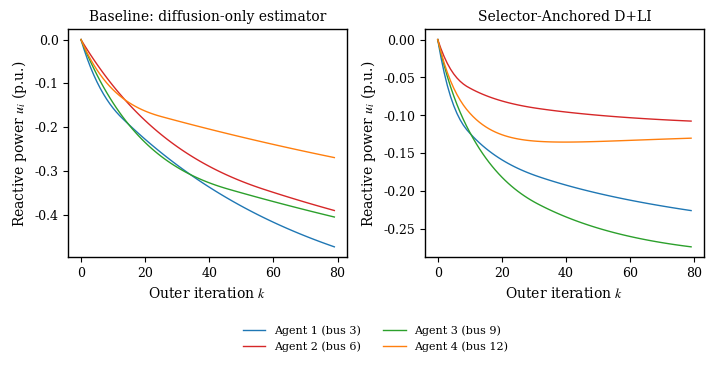

[save] fig_outer_diagnostics_smooth.pdf  


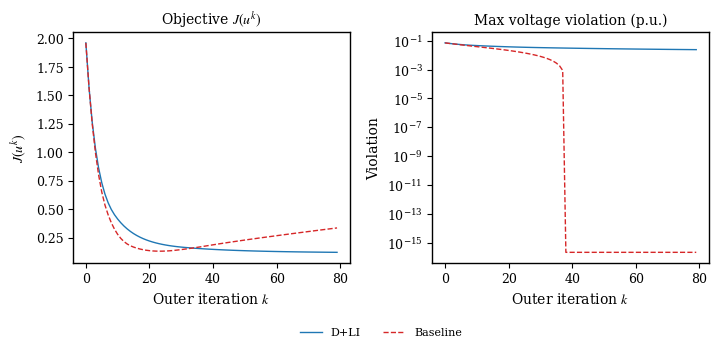

[save] fig_inner_diffusion_smooth.pdf  


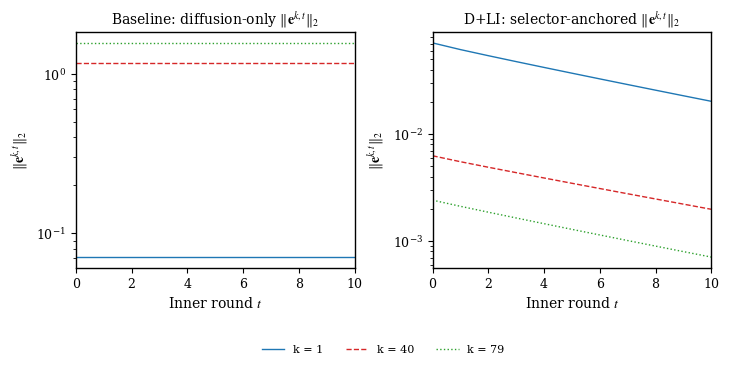

[save] fig_assembly_compare_smooth.pdf  


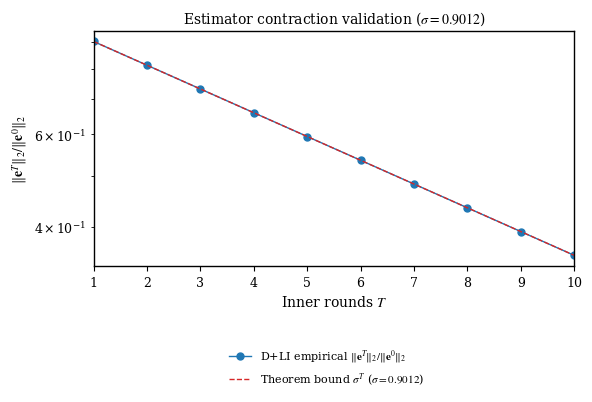

[save] fig_corollary1_smooth.pdf  


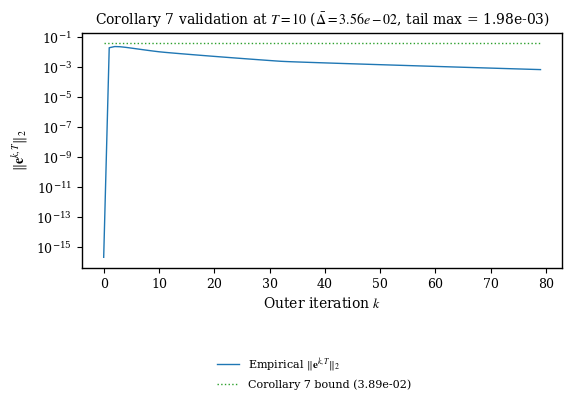


FINAL PARAMETER SUMMARY (for paper)
  N_BUS         = 12
  M (agents)    = 4  buses [3, 6, 9, 12]
  HOP_THRESH    = 4
  |E_comm|      = 5
  ITERATIONS    = 80
  T (inner)     = 10
  α (diffusion) = 0.249
  η (outer)     = 0.003
  σ = ‖A_sys‖₂  = 0.901227
  ‖X‖₂          = 0.810818
  L_bound       = 106.6882
  q_T           = 0.5797  (< 1: True)
  Tracking ratio= 0.3500
  Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)]
  Stressed buses= [3, 5, 8, 10, 12]
  Δ̄             = 3.5561e-02
  Cor.7 bound   = 3.8882e-02
  Tail max      = 1.9823e-03  (k >= 40)


In [ ]:
# Exp. B — matplotlib version (PDF-safe bars/sigma/delta)
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# CONFIG
SHOW_PLOTS = True
SAVE_PDF   = True
SAVE_PNG   = False   # optional raster export

# PLOT STYLE
FONT_SIZE   = 10
LEGEND_SIZE = 8
LINE_W      = 1.0
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})


# HELPERS
def _style_ax(ax):
    ax.set_facecolor("white")
    ax.tick_params(direction="out", which="both")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")
    return ax


def _bottom_legend(fig, handles, labels, ncol=2, y=0.02):
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        frameon=False,
        borderaxespad=0.0
    )


def _savefig(fig, stem):
    if SAVE_PDF:
        try:
            fig.savefig(f"{stem}.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
            print(f"[save] {stem}.pdf", end="  ")
        except Exception as e:
            print(f"[warn] PDF skipped ({e})", end="  ")
    if SAVE_PNG:
        try:
            fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
            print(f"[save] {stem}.png", end="  ")
        except Exception as e:
            print(f"[warn] PNG skipped ({e})", end="  ")
    print()
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


# PARAMETERS
SEED        = 42
N_BUS       = 12
PHYS_EDGES  = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CTRL_BUSES     = [3, 6, 9, 12]
STRESSED_BUSES = [3, 5, 8, 10, 12]        # 1-indexed, same convention as PHYS_EDGES
M              = len(CTRL_BUSES)

# Outer loop
ITERATIONS  = 80
ETA         = 0.003

# Inner loop
INNER_STEPS = 10
ALPHA       = 0.249
HOP_THRESH  = 4

# Physical model
V_NOM    = 1.02
V_BOOST  = 1.12
V_MAX    = 1.05
U_MIN    = -1.0
U_MAX    =  1.0
LAMBDA_C = 80.0
COSTS    = np.array([1.0, 1.5, 0.8, 1.2], float)

np.random.seed(SEED)
EPS = np.finfo(float).eps

# NETWORK SETUP
G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)

G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, ba in enumerate(CTRL_BUSES):
    for b, bb in enumerate(CTRL_BUSES):
        if b > a and nx.shortest_path_length(G_phys, ba, bb) <= HOP_THRESH:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError(
        f"Comm graph disconnected — increase HOP_THRESH (currently {HOP_THRESH})."
    )

L_c     = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
d_max   = int(max(dict(G_comm.degree()).values()))

if not (ALPHA < 1.0 / lam_max):
    raise ValueError(
        f"ALPHA={ALPHA} violates spectral bound 1/lam_max={1/lam_max:.4f}"
    )

W = np.eye(M) - ALPHA * L_c

assert np.allclose(W, W.T, atol=1e-12), "W not symmetric"
assert np.max(np.abs(W.sum(1) - 1.0)) < 1e-10, "W rows do not sum to 1"
assert np.min(W) >= -1e-12, "W has negative entries"

print("Feeder edges  =", sorted(tuple(sorted(e)) for e in G_phys.edges()),
      f"({G_phys.number_of_edges()} edges, tree={nx.is_tree(G_phys)})")
print("Stressed buses=", STRESSED_BUSES)
print("Comm edges    =", sorted(tuple(sorted((CTRL_BUSES[a], CTRL_BUSES[b])))

                                for a, b in G_comm.edges()))
print(
    f"Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
    f"d_max={d_max}, λ_max(L)={lam_max:.4f}, α={ALPHA}"
)

# PHYSICAL MODEL
#   V(u) = V_0 + X u
V_0 = np.full(N_BUS, V_NOM)
V_0[np.array(STRESSED_BUSES) - 1] = V_BOOST

X_mat = np.zeros((N_BUS, M))
for j in range(1, N_BUS + 1):
    for i, bi in enumerate(CTRL_BUSES):
        d = nx.shortest_path_length(G_phys, j, bi)
        X_mat[j - 1, i] = 0.4 * np.exp(-d / 1.5)


def voltages(u):
    return V_0 + X_mat @ np.asarray(u, float)


def max_violation(u):
    return float(max(0.0, np.max(voltages(u) - V_MAX)))


def global_obj(u):
    u = np.asarray(u, float)
    viol = np.maximum(0.0, voltages(u) - V_MAX)
    return 0.5 * float(np.dot(COSTS, u**2)) + LAMBDA_C * float(np.dot(viol, viol))


def local_grad(i, u_est):
    """Block gradient ∂J/∂u_i evaluated at u_est."""
    u_est = np.asarray(u_est, float)
    viol  = np.maximum(0.0, voltages(u_est) - V_MAX)
    return COSTS[i] * u_est[i] + 2.0 * LAMBDA_C * float(np.dot(viol, X_mat[:, i]))


# σ AND SMALL-GAIN CHECK
def _sigma(W_):
    d = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))


sigma   = _sigma(W)
sigma_T = sigma ** INNER_STEPS

# Conservative spectral bound for Lipschitz constant of g
X_op2   = float(np.linalg.norm(X_mat, 2))
L_bound = float(np.max(COSTS) + 2.0 * LAMBDA_C * (X_op2 ** 2))

q_T         = sigma_T * (1.0 + np.sqrt(M) * ETA * L_bound)   # Thm 6, eq. (24)
track_ratio = np.sqrt(M) * ETA * L_bound * sigma_T / (1.0 - sigma_T)

print(f"\nσ = ‖A_sys‖₂     = {sigma:.6f}")
print(f"σ^T              = {sigma_T:.6f}  (T={INNER_STEPS})")
print(f"‖X‖₂             = {X_op2:.6f}")
print(f"L_bound          = {L_bound:.4f}")
print(f"q_T (small-gain) = {q_T:.4f}  (< 1 required: {q_T < 1})")
print(f"Tracking ratio   = {track_ratio:.4f}")

if not (ETA < 1.0 / L_bound):
    warnings.warn(
        f"Step-size condition η < 1/L_bound violated: "
        f"η={ETA}, 1/L_bound={1.0 / L_bound:.4e}"
    )

if q_T >= 1.0:
    T_min = np.log(1.0 + np.sqrt(M) * ETA * L_bound) / np.log(1.0 / sigma)
    warnings.warn(
        f"Small-gain condition NOT satisfied (q_T={q_T:.4f}). "
        f"Minimum T ≥ {T_min:.1f}. Reduce ETA or increase INNER_STEPS."
    )

# ESTIMATOR DYNAMICS
def dli_step(S, u, W_):
    """
    Selector-Anchored D+LI:
        S^{t+1} = W S^t + diag(u - diag(S^t))
    """
    diag_old = np.diag(S).copy()
    S_new = W_ @ S
    idx = np.arange(len(u))
    S_new[idx, idx] += np.asarray(u, float) - diag_old
    return S_new


def diffusion_only_step(S, W_):
    """
    Diffusion-only baseline:
        S^{t+1} = W S^t
    """
    return W_ @ S


def stacked_err(S, u):
    """Frobenius norm to the row-replicated target matrix 1 u^T."""
    return float(np.linalg.norm((S - np.asarray(u, float)[None, :]).ravel(order="C")))


def proj_u(u):
    """Projection onto U = [U_MIN, U_MAX]^M."""
    return np.clip(np.asarray(u, float), U_MIN, U_MAX)

# EXPERIMENT 1 — BASELINE: DIFFUSION ONLY
u_base         = np.zeros(M)
S_base         = np.zeros((M, M))
H_base         = np.zeros((ITERATIONS, M))
viol_base      = np.zeros(ITERATIONS)
obj_base       = np.zeros(ITERATIONS)
assem_err_base = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_base[k]    = u_base.copy()
    viol_base[k] = max(max_violation(u_base), EPS)
    obj_base[k]  = global_obj(u_base)

    assem_err_base[k, 0] = max(stacked_err(S_base, u_base), EPS)

    for t in range(INNER_STEPS):
        S_base = diffusion_only_step(S_base, W)
        assem_err_base[k, t + 1] = max(stacked_err(S_base, u_base), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S_base[i])
        u_est[i] = u_base[i]
        u_next[i] = np.clip(u_base[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_base = u_next

# EXPERIMENT 2 — PROPOSED: SELECTOR-ANCHORED D+LI
u_loc     = np.zeros(M)
S         = np.zeros((M, M))
H_u       = np.zeros((ITERATIONS, M))
obj_dli   = np.zeros(ITERATIONS)
viol_dli  = np.zeros(ITERATIONS)
assem_err = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_u[k]      = u_loc.copy()
    obj_dli[k]  = global_obj(u_loc)
    viol_dli[k] = max(max_violation(u_loc), EPS)

    assem_err[k, 0] = max(stacked_err(S, u_loc), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        assem_err[k, t + 1] = max(stacked_err(S, u_loc), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S[i])
        u_est[i] = u_loc[i]
        u_next[i] = np.clip(u_loc[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_loc = u_next

obj_base_final  = global_obj(u_base)
viol_base_final = max(max_violation(u_base), EPS)
obj_dli_final   = global_obj(u_loc)
viol_dli_final  = max(max_violation(u_loc), EPS)

print(f"\nBaseline  final obj={obj_base_final:.4f}  viol={viol_base_final:.4e}")
print(f"D+LI      final obj={obj_dli_final:.4f}  viol={viol_dli_final:.4e}")

# ISS VALIDATION — FIXED u, DOMINANT-EIGENVECTOR INITIAL ERROR

Pblk_full = np.zeros((M * M, M * M))
for i in range(M):
    Pblk_full[i * M + i, i * M + i] = 1.0
A_sys = np.kron(W, np.eye(M)) - Pblk_full

eigvals, eigvecs = np.linalg.eigh(A_sys)
dom_idx = int(np.argmax(np.abs(eigvals)))
perturb = eigvecs[:, dom_idx].reshape(M, M, order="C")

u_fixed = np.zeros(M, float)
S_iss   = u_fixed[None, :] + perturb
n0_iss  = stacked_err(S_iss, u_fixed)

iss_norms = []
for _ in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms.append(max(stacked_err(S_iss, u_fixed), EPS))
iss_norms  = np.array(iss_norms)
T_range    = np.arange(1, INNER_STEPS + 1)
pred_sigma = np.array([sigma ** t * n0_iss for t in T_range])

# FINITE-HORIZON TRACKING BOUND
U_full    = np.vstack([H_u, u_loc[None, :]])
Delta_vec = np.linalg.norm(np.diff(U_full, axis=0), axis=1)
Delta_bar = float(np.max(Delta_vec)) if len(Delta_vec) > 0 else 0.0

cor1_bound = (np.sqrt(M) * sigma_T / (1.0 - sigma_T) * Delta_bar)

e_kT = assem_err[:, -1]
tail_start = ITERATIONS // 2
tail_max = float(np.max(e_kT[tail_start:]))

print(f"\nΔ̄ (empirical max ‖Δu^k‖) = {Delta_bar:.4e}")
print(f"Finite-horizon a posteriori bound ‖e^{{k,T}}‖ ≤ {cor1_bound:.4e}")
print(f"Tail max over k >= {tail_start}: {tail_max:.4e}")

# FIGURES
def fig_trajectories(stem="fig_traj_compare_smooth"):
    iters = np.arange(ITERATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
    ax1, ax2 = axes

    handles = []
    labels  = []

    for i in range(M):
        h1, = ax1.plot(
            iters, H_base[:, i],
            lw=LINE_W, color=COLORS[i],
            label=f"Agent {i+1} (bus {CTRL_BUSES[i]})"
        )
        ax2.plot(
            iters, H_u[:, i],
            lw=LINE_W, color=COLORS[i]
        )
        handles.append(h1)
        labels.append(f"Agent {i+1} (bus {CTRL_BUSES[i]})")

    ax1.set_title("Baseline: diffusion-only estimator")
    ax2.set_title("Selector-Anchored D+LI")

    for ax in axes:
        ax.set_xlabel(r"Outer iteration $k$")
        ax.set_ylabel(r"Reactive power $u_i$ (p.u.)")
        _style_ax(ax)

    _bottom_legend(fig, handles, labels, ncol=2, y=0.02)
    fig.subplots_adjust(bottom=0.28, wspace=0.28)
    _savefig(fig, stem)


def fig_outer_diagnostics(stem="fig_outer_diagnostics_smooth"):
    iters = np.arange(ITERATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))
    ax1, ax2 = axes

    h1, = ax1.plot(iters, obj_dli,  lw=LINE_W, color=COLORS[0], label="D+LI")
    h2, = ax1.plot(iters, obj_base, lw=LINE_W, color=COLORS[1], ls="--", label="Baseline")

    ax2.plot(iters, viol_dli,  lw=LINE_W, color=COLORS[0])
    ax2.plot(iters, viol_base, lw=LINE_W, color=COLORS[1], ls="--")

    ax1.set_title(r"Objective $J(u^k)$")
    ax2.set_title("Max voltage violation (p.u.)")

    ax1.set_xlabel(r"Outer iteration $k$")
    ax2.set_xlabel(r"Outer iteration $k$")
    ax1.set_ylabel(r"$J(u^k)$")
    ax2.set_ylabel("Violation")
    ax2.set_yscale("log")

    for ax in axes:
        _style_ax(ax)

    _bottom_legend(fig, [h1, h2], ["D+LI", "Baseline"], ncol=2, y=0.02)
    fig.subplots_adjust(bottom=0.24, wspace=0.30)
    _savefig(fig, stem)


def fig_inner_traces(ks=(1, ITERATIONS // 2, ITERATIONS - 1),
                     stem="fig_inner_diffusion_smooth"):
    ts = np.arange(INNER_STEPS + 1)
    dashes = ["solid", "dashed", "dotted"]

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
    ax1, ax2 = axes

    handles = []
    labels  = []

    for idx, k in enumerate(ks):
        h, = ax1.plot(
            ts, assem_err_base[k],
            lw=LINE_W, color=COLORS[idx], ls=dashes[idx],
            label=f"k = {k}"
        )
        ax2.plot(
            ts, assem_err[k],
            lw=LINE_W, color=COLORS[idx], ls=dashes[idx]
        )
        handles.append(h)
        labels.append(f"k = {k}")

    ax1.set_title(r"Baseline: diffusion-only $\|\mathbf{e}^{k,t}\|_2$")
    ax2.set_title(r"D+LI: selector-anchored $\|\mathbf{e}^{k,t}\|_2$")

    for ax in axes:
        ax.set_xlabel(r"Inner round $t$")
        ax.set_ylabel(r"$\|\mathbf{e}^{k,t}\|_2$")
        ax.set_xlim(0, INNER_STEPS)
        ax.set_xticks(np.arange(0, INNER_STEPS + 1, 2))
        ax.set_yscale("log")
        _style_ax(ax)

    _bottom_legend(fig, handles, labels, ncol=3, y=0.02)
    fig.subplots_adjust(bottom=0.26, wspace=0.28)
    _savefig(fig, stem)


def fig_assembly_compare(stem="fig_assembly_compare_smooth"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    h1, = ax.plot(
        T_range, ratio,
        lw=LINE_W, color=COLORS[0], marker="o", markersize=5,
        label=r"D+LI empirical $\|\mathbf{e}^{T}\|_2 / \|\mathbf{e}^{0}\|_2$"
    )
    h2, = ax.plot(
        T_range, bound,
        lw=LINE_W, color=COLORS[1], ls="--",
        label=rf"Theorem bound $\sigma^T$ ($\sigma = {sigma:.4f}$)"
    )

    ax.set_title(rf"Estimator contraction validation ($\sigma = {sigma:.4f}$)")
    ax.set_xlabel(r"Inner rounds $T$")
    ax.set_ylabel(r"$\|\mathbf{e}^{T}\|_2 / \|\mathbf{e}^{0}\|_2$")
    ax.set_xlim(1, INNER_STEPS)
    ax.set_xticks(np.arange(1, INNER_STEPS + 1, 1))
    ax.set_yscale("log")
    _style_ax(ax)

    _bottom_legend(fig, [h1, h2], [h1.get_label(), h2.get_label()], ncol=1, y=0.02)
    fig.subplots_adjust(bottom=0.32)
    _savefig(fig, stem)


def fig_corollary_validation(stem="fig_corollary1_smooth"):
    iters = np.arange(ITERATIONS)

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    h1, = ax.plot(
        iters, e_kT,
        lw=LINE_W, color=COLORS[0],
        label=r"Empirical $\|\mathbf{e}^{k,T}\|_2$"
    )
    h2, = ax.plot(
        iters, np.full(ITERATIONS, cor1_bound),
        lw=LINE_W, color=COLORS[2], ls=":",
        label=rf"Corollary 7 bound ({cor1_bound:.2e})"
    )

    ax.set_title(
        rf"Corollary 7 validation at $T={INNER_STEPS}$ "
        rf"($\bar{{\Delta}}={Delta_bar:.2e}$, tail max = {tail_max:.2e})"
    )
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$\|\mathbf{e}^{k,T}\|_2$")
    ax.set_yscale("log")
    _style_ax(ax)

    _bottom_legend(fig, [h1, h2], [h1.get_label(), h2.get_label()], ncol=1, y=0.02)
    fig.subplots_adjust(bottom=0.32)
    _savefig(fig, stem)


# RUN
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary_validation()


# SUMMARY
print("\n" + "=" * 58)
print("FINAL PARAMETER SUMMARY (for paper)")
print(f"  N_BUS         = {N_BUS}")
print(f"  M (agents)    = {M}  buses {CTRL_BUSES}")
print(f"  HOP_THRESH    = {HOP_THRESH}")
print(f"  |E_comm|      = {G_comm.number_of_edges()}")
print(f"  ITERATIONS    = {ITERATIONS}")
print(f"  T (inner)     = {INNER_STEPS}")
print(f"  α (diffusion) = {ALPHA}")
print(f"  η (outer)     = {ETA}")
print(f"  σ = ‖A_sys‖₂  = {sigma:.6f}")
print(f"  ‖X‖₂          = {X_op2:.6f}")
print(f"  L_bound       = {L_bound:.4f}")
print(f"  q_T           = {q_T:.4f}  (< 1: {q_T < 1})")
print(f"  Tracking ratio= {track_ratio:.4f}")
print(f"  Feeder edges  = {sorted(tuple(sorted(e)) for e in G_phys.edges())}")
print(f"  Stressed buses= {STRESSED_BUSES}")
print(f"  Δ̄             = {Delta_bar:.4e}")
print(f"  Cor.7 bound   = {cor1_bound:.4e}")
print(f"  Tail max      = {tail_max:.4e}  (k >= {tail_start})")
print("=" * 58)

# Exp B with Larger T

In [ ]:
# Exp. B
import warnings
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots


# CONFIG
SHOW_PLOTS = True
SAVE_PDF   = True
SAVE_HTML  = True

# PLOT STYLE
FONT_FAMILY = "Times New Roman"
FONT_SIZE   = 13
LEGEND_SIZE = 11
TEMPLATE    = "plotly_white"
LINE_W      = 2.5
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]


SIGMA = "\u03c3"

FONT_FAMILY = "DejaVu Serif"

XBAR     = "x̄"
SBAR     = "s̄"
SIGMA    = "σ"
DELTABAR = "Δ̄"

def _style(fig, width=700, height=400):
    fig.update_layout(
        template=TEMPLATE,
        font=dict(family=FONT_FAMILY, size=FONT_SIZE),
        width=width,
        height=height,
        margin=dict(l=65, r=25, t=55, b=60),
    )
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black",
                     mirror=True, ticks="outside")
    return fig


def _legend_bottom(fig, y=-0.20, b=95, size=None):
    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="top",
            y=y,
            xanchor="center",
            x=0.5,
            font=dict(size=LEGEND_SIZE if size is None else size),
            bgcolor="rgba(255,255,255,0)",
            borderwidth=0,
        ),
        margin=dict(b=b),
    )
    return fig

def _save(fig, stem):
    if SAVE_PDF:
        try:
            pio.write_image(fig, f"{stem}.pdf", format="pdf")
            print(f"[save] {stem}.pdf", end="  ")
        except Exception as e:
            print(f"[warn] PDF skipped ({e})", end="  ")
    if SAVE_HTML:
        fig.write_html(f"{stem}.html", include_plotlyjs="cdn")
        print(f"[save] {stem}.html")
    if SHOW_PLOTS:
        fig.show()


# PARAMETERS
SEED        = 42
N_BUS       = 12
PHYS_EDGES  = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CTRL_BUSES     = [3, 6, 9, 12]
STRESSED_BUSES = [3, 5, 8, 10, 12]        # 1-indexed, same convention as PHYS_EDGES
M              = len(CTRL_BUSES)

# Outer loop
ITERATIONS  = 80
ETA         = 0.003


# Inner loop
INNER_STEPS = 10          # main Experiment B run: small-gain / tracking
KL_INNER_STEPS = 15       # KL-witness run
ALPHA       = 0.249
HOP_THRESH  = 4

# KL witness tuple
KL_EPSILON = 5.0e-3
KL_TAU     = 0.5
KL_KAPPA_S = 10.0
KL_NU      = 1.0

# Physical model
V_NOM    = 1.02
V_BOOST  = 1.12
V_MAX    = 1.05
U_MIN    = -1.0
U_MAX    =  1.0
LAMBDA_C = 80.0
COSTS    = np.array([1.0, 1.5, 0.8, 1.2], float)

np.random.seed(SEED)
EPS = np.finfo(float).eps

# NETWORK SETUP

G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)

G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, ba in enumerate(CTRL_BUSES):
    for b, bb in enumerate(CTRL_BUSES):
        if b > a and nx.shortest_path_length(G_phys, ba, bb) <= HOP_THRESH:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError(
        f"Comm graph disconnected — increase HOP_THRESH (currently {HOP_THRESH})."
    )

L_c     = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
d_max   = int(max(dict(G_comm.degree()).values()))

if not (ALPHA < 1.0 / lam_max):
    raise ValueError(
        f"ALPHA={ALPHA} violates spectral bound 1/lam_max={1/lam_max:.4f}"
    )

W = np.eye(M) - ALPHA * L_c

assert np.allclose(W, W.T, atol=1e-12), "W not symmetric"
assert np.max(np.abs(W.sum(1) - 1.0)) < 1e-10, "W rows do not sum to 1"
assert np.min(W) >= -1e-12, "W has negative entries"
print("Feeder edges  =", sorted(tuple(sorted(e)) for e in G_phys.edges()),
      f"({G_phys.number_of_edges()} edges, tree={nx.is_tree(G_phys)})")
print("Stressed buses=", STRESSED_BUSES)
print("Comm edges    =", sorted(tuple(sorted((CTRL_BUSES[a], CTRL_BUSES[b])))
                                for a, b in G_comm.edges()))
print(
    f"Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
    f"d_max={d_max}, λ_max(L)={lam_max:.4f}, α={ALPHA}"
)

# PHYSICAL MODEL
#   V(u) = V_0 + X u
V_0 = np.full(N_BUS, V_NOM)
V_0[np.array(STRESSED_BUSES) - 1] = V_BOOST

X_mat = np.zeros((N_BUS, M))
for j in range(1, N_BUS + 1):
    for i, bi in enumerate(CTRL_BUSES):
        d = nx.shortest_path_length(G_phys, j, bi)
        X_mat[j - 1, i] = 0.4 * np.exp(-d / 1.5)


def voltages(u):
    return V_0 + X_mat @ np.asarray(u, float)


def max_violation(u):
    return float(max(0.0, np.max(voltages(u) - V_MAX)))


def global_obj(u):
    u = np.asarray(u, float)
    viol = np.maximum(0.0, voltages(u) - V_MAX)
    return 0.5 * float(np.dot(COSTS, u**2)) + LAMBDA_C * float(np.dot(viol, viol))


def local_grad(i, u_est):
    """Block gradient ∂J/∂u_i evaluated at u_est."""
    u_est = np.asarray(u_est, float)
    viol  = np.maximum(0.0, voltages(u_est) - V_MAX)
    return COSTS[i] * u_est[i] + 2.0 * LAMBDA_C * float(np.dot(viol, X_mat[:, i]))


# σ AND SMALL-GAIN CHECK
def _sigma(W_):
    d = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))


sigma   = _sigma(W)
sigma_T = sigma ** INNER_STEPS

# Conservative spectral bound for Lipschitz constant of g
X_op2   = float(np.linalg.norm(X_mat, 2))
L_bound = float(np.max(COSTS) + 2.0 * LAMBDA_C * (X_op2 ** 2))

q_T = sigma_T * (
    1.0 + np.sqrt(M) * ETA * L_bound
)

track_ratio = (
    np.sqrt(M)
    * ETA
    * L_bound
    * sigma_T
    / (1.0 - sigma_T)
)

print(f"\nσ = ‖A_sys‖₂     = {sigma:.6f}")
print(f"σ^T              = {sigma_T:.6f}  (T={INNER_STEPS})")
print(f"L_bound          = {L_bound:.4f}")
print(f"q_T              = {q_T:.4f}  (< 1 required: {q_T < 1})")
print(f"Tracking ratio   = {track_ratio:.4f}")

if not (ETA < 1.0 / L_bound):
    warnings.warn(
        f"Step-size condition η < 1/L_bound violated: "
        f"η={ETA}, 1/L_bound={1.0 / L_bound:.4e}"
    )

if q_T >= 1.0:
    T_threshold = (
        np.log(1.0 + np.sqrt(M) * ETA * L_bound)
        / np.log(1.0 / sigma)
    )
    warnings.warn(
        f"Small-gain condition NOT satisfied (q_T={q_T:.4f}). "
        f"The strict condition requires T > {T_threshold:.2f}. "
        f"Reduce ETA or increase INNER_STEPS."
    )

# ESTIMATOR DYNAMICS
def dli_step(S, u, W_):
    """
    Selector-Anchored D+LI:
        S^{t+1} = W S^t + diag(u - diag(S^t))
    """
    diag_old = np.diag(S).copy()
    S_new = W_ @ S
    idx = np.arange(len(u))
    S_new[idx, idx] += np.asarray(u, float) - diag_old
    return S_new


def diffusion_only_step(S, W_):
    """
    Diffusion-only baseline:
        S^{t+1} = W S^t
    No selector anchoring or local-truth injection is applied to the
    estimator state.
    """
    return W_ @ S


def stacked_err(S, u):
    """Frobenius norm to the row-replicated target matrix 1 u^T."""
    return float(np.linalg.norm((S - np.asarray(u, float)[None, :]).ravel(order="C")))


def proj_u(u):
    """Projection onto U = [U_MIN, U_MAX]^M."""
    return np.clip(np.asarray(u, float), U_MIN, U_MAX)


# EXPERIMENT 1 — BASELINE: DIFFUSION ONLY, NO SELECTOR ANCHORING
# The estimator evolves only by diffusion:
#     S^{t+1} = W S^t
# No local-truth refresh is injected into the estimator state.
# At gradient evaluation, agent i still knows its own current block exactly,
# so we overwrite u_est[i] = u_base[i] before computing the local gradient.
u_base         = np.zeros(M)
S_base         = np.zeros((M, M))
H_base         = np.zeros((ITERATIONS, M))
viol_base      = np.zeros(ITERATIONS)
obj_base       = np.zeros(ITERATIONS)
assem_err_base = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_base[k]    = u_base.copy()
    viol_base[k] = max(max_violation(u_base), EPS)
    obj_base[k]  = global_obj(u_base)

    # pre-inner-loop estimator error
    assem_err_base[k, 0] = max(stacked_err(S_base, u_base), EPS)

    for t in range(INNER_STEPS):
        S_base = diffusion_only_step(S_base, W)
        assem_err_base[k, t + 1] = max(stacked_err(S_base, u_base), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S_base[i])
        u_est[i] = u_base[i]   # exact owned coordinate at gradient evaluation
        u_next[i] = np.clip(u_base[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_base = u_next



# EXPERIMENT 2 — PROPOSED: SELECTOR-ANCHORED D+LI
u_loc     = np.zeros(M)
S         = np.zeros((M, M))
H_u       = np.zeros((ITERATIONS, M))
obj_dli   = np.zeros(ITERATIONS)
viol_dli  = np.zeros(ITERATIONS)
assem_err = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_u[k]      = u_loc.copy()
    obj_dli[k]  = global_obj(u_loc)
    viol_dli[k] = max(max_violation(u_loc), EPS)

    assem_err[k, 0] = max(stacked_err(S, u_loc), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        assem_err[k, t + 1] = max(stacked_err(S, u_loc), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S[i])
        u_est[i] = u_loc[i]   # exact owned coordinate at gradient evaluation
        u_next[i] = np.clip(u_loc[i] - ETA * local_grad(i, u_est), U_MIN, U_MAX)
    u_loc = u_next

obj_base_final  = global_obj(u_base)
viol_base_final = max(max_violation(u_base), EPS)
obj_dli_final   = global_obj(u_loc)
viol_dli_final  = max(max_violation(u_loc), EPS)

print(f"\nBaseline  final obj={obj_base_final:.4f}  viol={viol_base_final:.4e}")
print(f"D+LI      final obj={obj_dli_final:.4f}  viol={viol_dli_final:.4e}")

# ISS VALIDATION — FIXED u, DOMINANT-EIGENVECTOR INITIAL ERROR
# This validates Theorem 1 / contraction:
#   ||e^T|| <= sigma^T ||e^0||
Pblk_full = np.zeros((M * M, M * M))
for i in range(M):
    Pblk_full[i * M + i, i * M + i] = 1.0
A_sys = np.kron(W, np.eye(M)) - Pblk_full

eigvals, eigvecs = np.linalg.eigh(A_sys)
dom_idx = int(np.argmax(np.abs(eigvals)))
perturb = eigvecs[:, dom_idx].reshape(M, M, order="C")

u_fixed = np.zeros(M, float)   # deterministic fixed point
S_iss   = u_fixed[None, :] + perturb
n0_iss  = stacked_err(S_iss, u_fixed)

iss_norms = []
for _ in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms.append(max(stacked_err(S_iss, u_fixed), EPS))
iss_norms  = np.array(iss_norms)
T_range    = np.arange(1, INNER_STEPS + 1)
pred_sigma = np.array([sigma ** t * n0_iss for t in T_range])

# FINITE-HORIZON A POSTERIORI TRACKING BOUND
# Corollary object:
#   ||e^{k,T}||  over outer iterations k
# Bound:
#   sqrt(M) sigma^T / (1 - sigma^T) * Delta_bar
U_full    = np.vstack([H_u, u_loc[None, :]])
Delta_vec = np.linalg.norm(np.diff(U_full, axis=0), axis=1)
Delta_bar = float(np.max(Delta_vec)) if len(Delta_vec) > 0 else 0.0

cor1_bound = (np.sqrt(M) * sigma_T / (1.0 - sigma_T) * Delta_bar)

# empirical e^{k,T} sequence from the actual two-timescale run
e_kT = assem_err[:, -1]
tail_start = ITERATIONS // 2
tail_max = float(np.max(e_kT[tail_start:]))

print(f"\nΔ̄ (empirical max ‖Δu^k‖) = {Delta_bar:.4e}")
print(f"Finite-horizon a posteriori bound ‖e^{{k,T}}‖ ≤ {cor1_bound:.4e}")
print(f"Tail max over k >= {tail_start}: {tail_max:.4e}")

# KL-WITNESS RUN — T = 15
# This run is separate from the T=10 small-gain/tracking run.
# It witnesses the pointwise KL timescale condition and produces
# the finite-length diagnostic:
#   L_K = sum_{k=0}^{K-1} ||xi^{k+1} - xi^k||
# where xi^k = (u^k, S^{k,0}).
def run_dli_for_T(T_inner):
    u = np.zeros(M)
    S_warm = np.zeros((M, M))

    xi_inc = np.zeros(ITERATIONS)
    path_len = np.zeros(ITERATIONS)

    xi_prev = np.concatenate([u.ravel(), S_warm.ravel(order="C")])

    obj_hist = np.zeros(ITERATIONS)
    viol_hist = np.zeros(ITERATIONS)

    for k in range(ITERATIONS):
        obj_hist[k] = global_obj(u)
        viol_hist[k] = max(max_violation(u), EPS)

        for _ in range(T_inner):
            S_warm = dli_step(S_warm, u, W)

        u_next = np.empty(M, float)
        for i in range(M):
            u_est = proj_u(S_warm[i])
            u_est[i] = u[i]
            u_next[i] = np.clip(
                u[i] - ETA * local_grad(i, u_est),
                U_MIN,
                U_MAX
            )

        # xi^{k+1} = (u^{k+1}, S^{k+1,0}), with S^{k+1,0}=S^{k,T}
        xi_next = np.concatenate([u_next.ravel(), S_warm.ravel(order="C")])
        xi_inc[k] = max(float(np.linalg.norm(xi_next - xi_prev)), EPS)
        path_len[k] = xi_inc[k] if k == 0 else path_len[k - 1] + xi_inc[k]

        u = u_next
        xi_prev = xi_next

    return u, S_warm, xi_inc, path_len, obj_hist, viol_hist


# KL constants
a_kl = sigma ** KL_INNER_STEPS

C_u_kl = 1.0 / (2.0 * KL_EPSILON)
C_e_kl = 0.5 * KL_EPSILON * (L_bound ** 2)
tilde_C_e_kl = C_e_kl + 0.5 * KL_KAPPA_S * KL_TAU

tilde_c_u_kl = (
    1.0 / ETA
    - 0.5 * L_bound
    - C_u_kl
    - 0.5 * KL_KAPPA_S * (1.0 + 1.0 / KL_TAU) * M
)

c_s_kl = 0.5 * KL_KAPPA_S * (1.0 - a_kl) / (1.0 + a_kl)

pointwise_margin_kl = (
    c_s_kl
    - tilde_C_e_kl * (a_kl / (1.0 - a_kl)) ** 2
)

Gamma_e_kl = (
    (1.0 + 1.0 / KL_NU)
    * M
    * (a_kl ** 2)
    / ((1.0 - a_kl) ** 2)
)

summed_margin_kl = tilde_c_u_kl - tilde_C_e_kl * Gamma_e_kl

T_min_abs_kl = int(np.ceil(
    np.log(
        1.0
        + np.sqrt((1.0 + 1.0 / KL_NU) * M * tilde_C_e_kl / tilde_c_u_kl)
    )
    / np.log(1.0 / sigma)
))

t_abs_ratio = (
    np.log(
        1.0
        + np.sqrt(
            (1.0 + 1.0 / KL_NU)
            * M
            * tilde_C_e_kl
            / tilde_c_u_kl
        )
    )
    / np.log(1.0 / sigma)
)

# Strict condition: T > t_abs_ratio
T_min_abs_kl = int(np.floor(t_abs_ratio)) + 1

u_kl, S_kl, xi_inc_kl, path_len_kl, obj_kl, viol_kl = run_dli_for_T(
    KL_INNER_STEPS
)

print("\nKL-WITNESS PARAMETER TUPLE")
print(f"  T_KL          = {KL_INNER_STEPS}")
print(f"  a = σ^T       = {a_kl:.4f}")
print(f"  ε             = {KL_EPSILON:.4e}")
print(f"  τ             = {KL_TAU:.4f}")
print(f"  κ_s           = {KL_KAPPA_S:.4f}")
print(f"  ν             = {KL_NU:.4f}")
print(f"  C_u           = {C_u_kl:.3f}")
print(f"  C_e           = {C_e_kl:.3f}")
print(f"  C̃_e          = {tilde_C_e_kl:.3f}")
print(f"  c̃_u          = {tilde_c_u_kl:.3f}")
print(f"  c_s           = {c_s_kl:.3f}")
print(f"  point margin  = {pointwise_margin_kl:.3f}  (> 0: {pointwise_margin_kl > 0})")
print(f"  Γ_e           = {Gamma_e_kl:.3f}")
print(f"  summed margin = {summed_margin_kl:.3f}  (> 0: {summed_margin_kl > 0})")
print(f"  T_min_abs     = {T_min_abs_kl}")
print(f"  final Δξ      = {xi_inc_kl[-1]:.4e}")
print(f"  final L_K     = {path_len_kl[-1]:.4e}")

# FIGURES

# ── Fig 1: Decision trajectories ────────────────────────────
def fig_trajectories(stem="fig_traj_compare_smooth"):
    iters = np.arange(ITERATIONS)
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.13,
        subplot_titles=(
            "Pure-mixing ablation",
            "Selector-Anchored D+LI"
        )
    )

    for i in range(M):
        fig.add_trace(
            go.Scatter(
                x=iters, y=H_base[:, i], mode="lines",
                line=dict(width=LINE_W, color=COLORS[i]),
                name=f"Agent {i+1} (bus {CTRL_BUSES[i]})"
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=iters, y=H_u[:, i], mode="lines",
                line=dict(width=LINE_W, color=COLORS[i]),
                showlegend=False
            ),
            row=1, col=2
        )

    for col in [1, 2]:
        fig.update_xaxes(title_text="Outer iteration k", row=1, col=col)
        fig.update_yaxes(
            title_text="Reactive power u<sub>i</sub> (p.u.)", row=1, col=col
        )

    _style(fig, width=820, height=380)
    #_legend_bottom(fig)
    _legend_bottom(fig, y=-0.30, b=135, size=10)
    _save(fig, stem)


# ── Fig 2: Outer diagnostics ────────────────────────────────
def fig_outer_diagnostics(stem="fig_outer_diagnostics_smooth"):
    iters = np.arange(ITERATIONS)
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.15,
        subplot_titles=(
            "Objective J(u<sup>k</sup>)",
            "Max voltage violation (p.u.)"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=iters, y=obj_dli, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="D+LI"
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=obj_base, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name="Pure mixing"
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=viol_dli, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            showlegend=False
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(
            x=iters, y=viol_base, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            showlegend=False
        ),
        row=1, col=2
    )

    for col in [1, 2]:
        fig.update_xaxes(title_text="Outer iteration k", row=1, col=col)
    fig.update_yaxes(title_text="J(u<sup>k</sup>)", row=1, col=1)
    fig.update_yaxes(title_text="Violation (log scale)", type="log", row=1, col=2)

    _style(fig, width=820, height=360)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 3: Inner assembly residual ──────────────────────────
def fig_inner_traces(ks=(1, ITERATIONS // 2, ITERATIONS - 1),
                     stem="fig_inner_diffusion_smooth"):
    ts     = np.arange(INNER_STEPS + 1)
    dashes = ["solid", "dash", "dot"]
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.13,
        subplot_titles=(
            "Baseline: diffusion-only ||e<sup>k,t</sup>||",
            "D+LI: selector-anchored ||e<sup>k,t</sup>||"
        )
    )

    for idx, k in enumerate(ks):
        fig.add_trace(
            go.Scatter(
                x=ts, y=assem_err_base[k], mode="lines",
                line=dict(width=LINE_W, color=COLORS[idx], dash=dashes[idx]),
                name=f"k = {k}"
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=ts, y=assem_err[k], mode="lines",
                line=dict(width=LINE_W, color=COLORS[idx], dash=dashes[idx]),
                showlegend=False
            ),
            row=1, col=2
        )

    for col in [1, 2]:
        fig.update_xaxes(
            title_text="Inner round t",
            range=[0, INNER_STEPS],
            tickmode="linear",
            dtick=2,
            row=1, col=col
        )
        fig.update_yaxes(
            title_text="||e<sup>k,t</sup>|| (log scale)",
            type="log",
            row=1, col=col
            )

    _style(fig, width=820, height=380)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 4: ISS validation ───────────────────────────────────
def fig_assembly_compare(stem="fig_assembly_compare_smooth"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig = go.Figure([
        go.Scatter(
            x=T_range, y=ratio, mode="lines+markers",
            line=dict(width=LINE_W, color=COLORS[0]),
            marker=dict(size=5),
            name="D+LI empirical ||e<sup>T</sup>|| / ||e<sup>0</sup>||"
        ),
        go.Scatter(
            x=T_range, y=bound, mode="lines",
            line=dict(width=LINE_W, color=COLORS[1], dash="dash"),
            name=f"Theorem bound {SIGMA}<sup>T</sup> ({SIGMA} = {sigma:.4f})"
        ),
    ])

    fig.update_xaxes(
        title_text="Inner rounds T",
        range=[1, INNER_STEPS],
        tickmode="linear",
        dtick=1
    )
    fig.update_yaxes(
        title_text="||e<sup>T</sup>|| / ||e<sup>0</sup>|| (log scale)",
        type="log"
    )
    #fig.update_layout(
    #    title=dict(
    #        text=f"Estimator contraction validation ({SIGMA} = {sigma:.4f})",
    #        x=0.5
    #    )
    #)

    _style(fig, width=620, height=420)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 5: Finite-horizon tracking diagnostic ─────────────────────
def fig_corollary_validation(stem="fig_corollary1_smooth"):
    iters = np.arange(ITERATIONS)

    fig = go.Figure([
        go.Scatter(
            x=iters, y=e_kT, mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="Empirical ||e<sup>k,T</sup>||"
        ),
        go.Scatter(
            x=iters, y=np.full(ITERATIONS, cor1_bound), mode="lines",
            line=dict(width=LINE_W, color=COLORS[2], dash="dot"),
            name=f"Tracking bound ({cor1_bound:.2e})"
        ),
    ])

    fig.update_xaxes(title_text="Outer iteration k")
    fig.update_yaxes(
        title_text="||e<sup>k,T</sup>|| (log scale)",
        type="log"
    )
    fig.update_layout(
    title=dict(
        text=(
            f"Finite-horizon tracking diagnostic at T = {INNER_STEPS} "
            f"({DELTABAR} = {Delta_bar:.2e}, tail max = {tail_max:.2e})"
        ),
        x=0.5
    )
)
    _style(fig, width=620, height=420)
    _legend_bottom(fig)
    _save(fig, stem)


# ── Fig 6: KL finite-length diagnostic ──────────────────────
def fig_finite_length_smooth(stem="fig_finite_length_smooth"):
    iters = np.arange(1, ITERATIONS + 1)

    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.15,
        subplot_titles=(
            "Cumulative finite length",
            "Increment norm"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=iters,
            y=path_len_kl,
            mode="lines",
            line=dict(width=LINE_W, color=COLORS[0]),
            name="L<sub>K</sub>"
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=iters,
            y=xi_inc_kl,
            mode="lines",
            line=dict(width=LINE_W, color=COLORS[1]),
            name="||ξ<sup>k+1</sup> − ξ<sup>k</sup>||"
        ),
        row=1, col=2
    )

    fig.update_xaxes(title_text="Outer iteration K", row=1, col=1)
    fig.update_xaxes(title_text="Outer iteration k", row=1, col=2)
    fig.update_yaxes(title_text="L<sub>K</sub>", row=1, col=1)
    fig.update_yaxes(
        title_text="Increment norm (log scale)",
        type="log",
        row=1,
        col=2
    )

    fig.update_layout(
        title=dict(
            text=(
                f"KL finite-length diagnostic "
                f"(T = {KL_INNER_STEPS}, final Δξ = {xi_inc_kl[-1]:.2e})"
            ),
            x=0.5
        )
    )

    _style(fig, width=820, height=380)
    _legend_bottom(fig)
    _save(fig, stem)
# RUN
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary_validation()
fig_finite_length_smooth()

# SUMMARY
print(f"  KL T          = {KL_INNER_STEPS}")
print(f"  KL σ^T        = {a_kl:.4f}")
print(f"  KL c̃_u        = {tilde_c_u_kl:.3f}")
print(f"  KL c_s margin = {pointwise_margin_kl:.3f}")
print(f"  KL sum margin = {summed_margin_kl:.3f}")
print(f"  KL final Δξ   = {xi_inc_kl[-1]:.4e}")
print(f"  KL final L_K  = {path_len_kl[-1]:.4e}")

print("\n" + "=" * 58)
print("FINAL PARAMETER SUMMARY (for paper)")
print(f"  N_BUS         = {N_BUS}")
print(f"  M (agents)    = {M}  buses {CTRL_BUSES}")
print(f"  HOP_THRESH    = {HOP_THRESH}")
print(f"  |E_comm|      = {G_comm.number_of_edges()}")
print(f"  ITERATIONS    = {ITERATIONS}")
print(f"  T (inner)     = {INNER_STEPS}")
print(f"  α (diffusion) = {ALPHA}")
print(f"  η (outer)     = {ETA}")
print(f"  σ = ‖A_sys‖₂  = {sigma:.6f}")
print(f"  ‖X‖₂          = {X_op2:.6f}")
print(f"  L_bound       = {L_bound:.4f}")
print(f"  q_T           = {q_T:.4f}  (< 1: {q_T < 1})")
print(f"  Tracking ratio= {track_ratio:.4f}")
print(f"  Feeder edges  = {sorted(tuple(sorted(e)) for e in G_phys.edges())}")
print(f"  Stressed buses= {STRESSED_BUSES}")
print(f"  Δ̄             = {Delta_bar:.4e}")
print(f"  Tracking bound   = {cor1_bound:.4e}")
print(f"  Tail max      = {tail_max:.4e}  (k >= {tail_start})")
print("=" * 58)

Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)] (11 edges, tree=True)
Stressed buses= [3, 5, 8, 10, 12]
Comm edges    = [(3, 6), (3, 9), (3, 12), (6, 9), (6, 12)]
Comm graph: 4 nodes, 5 edges, d_max=3, λ_max(L)=4.0000, α=0.249

σ = ‖A_sys‖₂     = 0.901227
σ^T              = 0.353461  (T=10)
L_bound          = 106.6882
q_T              = 0.5797  (< 1 required: True)
Tracking ratio   = 0.3500

Baseline  final obj=0.3393  viol=2.2204e-16
D+LI      final obj=0.1216  viol=2.3664e-02

Δ̄ (empirical max ‖Δu^k‖) = 3.5561e-02
Finite-horizon a posteriori bound ‖e^{k,T}‖ ≤ 3.8882e-02
Tail max over k >= 40: 1.9823e-03

KL-WITNESS PARAMETER TUPLE
  T_KL          = 15
  a = σ^T       = 0.2101
  ε             = 5.0000e-03
  τ             = 0.5000
  κ_s           = 10.0000
  ν             = 1.0000
  C_u           = 100.000
  C_e           = 28.456
  C̃_e          = 30.956
  c̃_u          = 119.989
  c_s           = 3.263
  point margin  = 1.

[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_outer_diagnostics_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_inner_diffusion_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_assembly_compare_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_corollary1_smooth.html


[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_finite_length_smooth.html


  KL T          = 15
  KL σ^T        = 0.2101
  KL c̃_u        = 119.989
  KL c_s margin = 1.072
  KL sum margin = 102.460
  KL final Δξ   = 1.9357e-03
  KL final L_K  = 9.2581e-01

FINAL PARAMETER SUMMARY (for paper)
  N_BUS         = 12
  M (agents)    = 4  buses [3, 6, 9, 12]
  HOP_THRESH    = 4
  |E_comm|      = 5
  ITERATIONS    = 80
  T (inner)     = 10
  α (diffusion) = 0.249
  η (outer)     = 0.003
  σ = ‖A_sys‖₂  = 0.901227
  ‖X‖₂          = 0.810818
  L_bound       = 106.6882
  q_T           = 0.5797  (< 1: True)
  Tracking ratio= 0.3500
  Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)]
  Stressed buses= [3, 5, 8, 10, 12]
  Δ̄             = 3.5561e-02
  Tracking bound   = 3.8882e-02
  Tail max      = 1.9823e-03  (k >= 40)


Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)] (11 edges, tree=True)
Stressed buses= [3, 5, 8, 10, 12]
Comm edges    = [(3, 6), (3, 9), (3, 12), (6, 9), (6, 12)]
Comm graph: 4 nodes, 5 edges, d_max=3, λ_max(L)=4.0000, α=0.249

σ = ‖A_sys‖₂     = 0.901227
σ^T              = 0.353461  (T=10)
L_bound          = 106.6882
q_T              = 0.5797  (< 1 required: True)
Tracking ratio   = 0.3500

Baseline  final obj=0.3393  viol=2.2204e-16
D+LI      final obj=0.1216  viol=2.3664e-02

Δ̄ (empirical max ‖Δu^k‖) = 3.5561e-02
Finite-horizon a posteriori bound ‖e^{k,T}‖ ≤ 3.8882e-02
Tail max over k >= 40: 1.9823e-03

KL-WITNESS PARAMETER TUPLE
  T_KL          = 15
  a = σ^T       = 0.2101
  ε             = 5.0000e-03
  τ             = 0.5000
  κ_s           = 10.0000
  ν             = 1.0000
  C_u           = 100.000
  C_e           = 28.456
  C̃_e          = 30.956
  c̃_u          = 119.989
  c_s           = 3.263
  point margin  = 1.

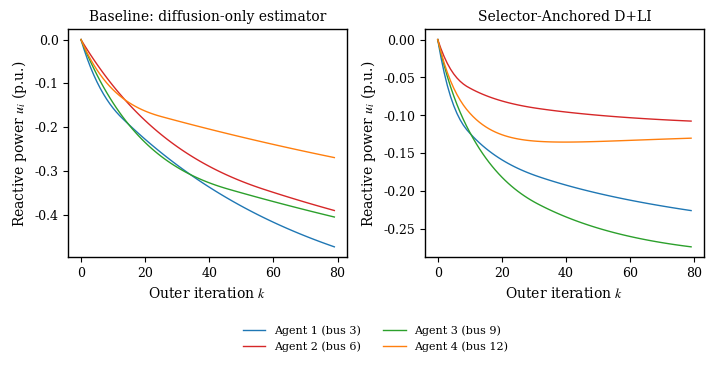

[save] fig_outer_diagnostics_smooth.pdf  


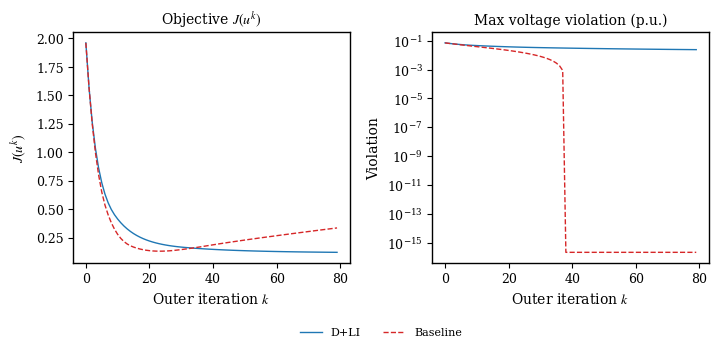

[save] fig_inner_diffusion_smooth.pdf  


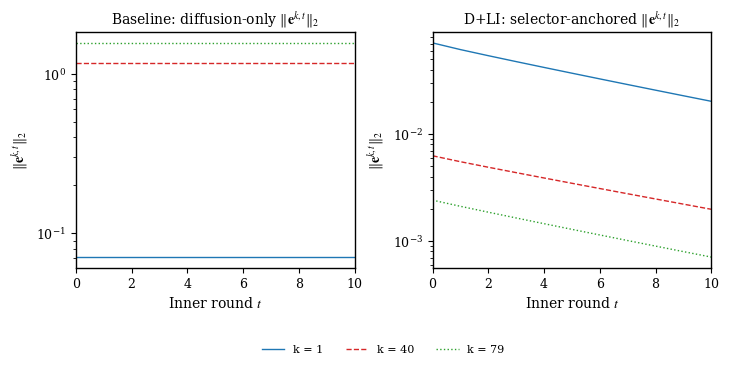

[save] fig_assembly_compare_smooth.pdf  


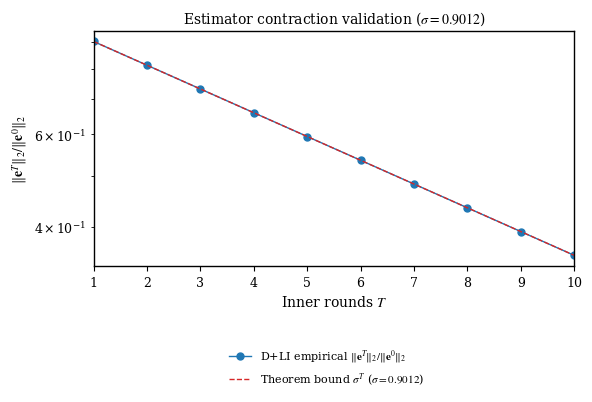

[save] fig_corollary1_smooth.pdf  


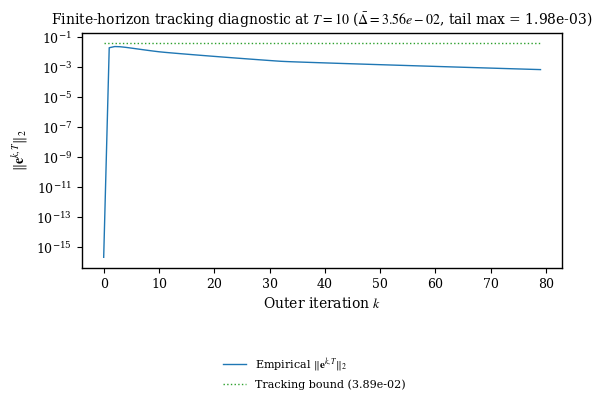

[save] fig_finite_length_smooth.pdf  


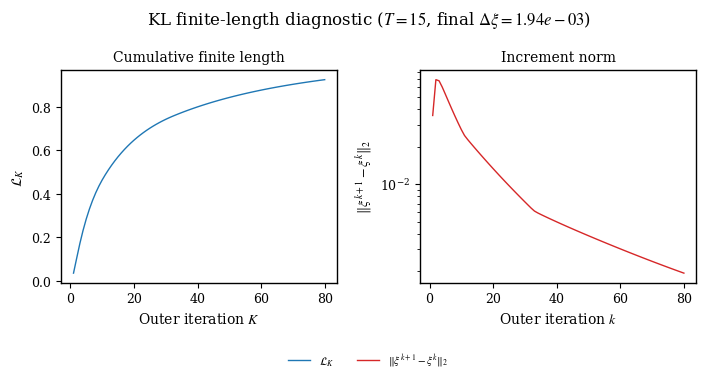


FINAL PARAMETER SUMMARY (for paper)
  N_BUS         = 12
  M (agents)    = 4  buses [3, 6, 9, 12]
  HOP_THRESH    = 4
  |E_comm|      = 5
  ITERATIONS    = 80
  T (inner)     = 10
  α (diffusion) = 0.249
  η (outer)     = 0.003
  σ = ‖A_sys‖₂  = 0.901227
  ‖X‖₂          = 0.810818
  L_bound       = 106.6882
  q_T           = 0.5797  (< 1: True)
  Tracking ratio= 0.3500
  Feeder edges  = [(1, 2), (2, 3), (2, 11), (3, 4), (3, 6), (4, 5), (4, 8), (5, 9), (6, 7), (9, 10), (11, 12)]
  Stressed buses= [3, 5, 8, 10, 12]
  Δ̄             = 3.5561e-02
  Tracking bound   = 3.8882e-02
  Tail max      = 1.9823e-03  (k >= 40)

KL-WITNESS SUMMARY
  KL T          = 15
  KL σ^T        = 0.2101
  KL ε          = 5.0000e-03
  KL τ          = 0.5000
  KL κ_s        = 10.0000
  KL ν          = 1.0000
  KL C_u        = 100.000
  KL C_e        = 28.456
  KL C̃_e       = 30.956
  KL c̃_u       = 119.989
  KL c_s        = 3.263
  KL c_s margin = 1.072
  KL Γ_e        = 0.566
  KL sum margin = 102.460
  KL T_

In [ ]:
# Exp. B — matplotlib version (PDF-safe bars/sigma/delta)
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# CONFIG

SHOW_PLOTS = True
SAVE_PDF   = True
SAVE_PNG   = False   # optional raster export

# PLOT STYLE
FONT_SIZE   = 10
LEGEND_SIZE = 8
LINE_W      = 1.0
COLORS      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})



# HELPERS
def _style_ax(ax):
    ax.set_facecolor("white")
    ax.tick_params(direction="out", which="both")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")
    return ax


def _bottom_legend(fig, handles, labels, ncol=2, y=0.02):
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        frameon=False,
        borderaxespad=0.0
    )


def _savefig(fig, stem):
    if SAVE_PDF:
        try:
            fig.savefig(
                f"{stem}.pdf",
                format="pdf",
                bbox_inches="tight",
                pad_inches=0.02
            )
            print(f"[save] {stem}.pdf", end="  ")
        except Exception as e:
            print(f"[warn] PDF skipped ({e})", end="  ")

    if SAVE_PNG:
        try:
            fig.savefig(
                f"{stem}.png",
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.02
            )
            print(f"[save] {stem}.png", end="  ")
        except Exception as e:
            print(f"[warn] PNG skipped ({e})", end="  ")

    print()

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


# PARAMETERS
SEED        = 42
N_BUS       = 12
PHYS_EDGES  = [
    (1, 2), (2, 3), (3, 4), (4, 5), (3, 6), (6, 7),
    (4, 8), (5, 9), (9, 10), (2, 11), (11, 12)
]
CTRL_BUSES     = [3, 6, 9, 12]
STRESSED_BUSES = [3, 5, 8, 10, 12]        # 1-indexed, same convention as PHYS_EDGES
M              = len(CTRL_BUSES)

# Outer loop
ITERATIONS  = 80
ETA         = 0.003

# Inner loop
INNER_STEPS    = 10          # main Experiment B run: small-gain / tracking
KL_INNER_STEPS = 15          # KL-witness run
KL_ITERATIONS  = ITERATIONS  # same horizon as main run
ALPHA          = 0.249
HOP_THRESH     = 4

# KL witness tuple
KL_EPSILON = 5.0e-3
KL_TAU     = 0.5
KL_KAPPA_S = 10.0
KL_NU      = 1.0

# Physical model
V_NOM    = 1.02
V_BOOST  = 1.12
V_MAX    = 1.05
U_MIN    = -1.0
U_MAX    =  1.0
LAMBDA_C = 80.0
COSTS    = np.array([1.0, 1.5, 0.8, 1.2], float)

np.random.seed(SEED)
EPS = np.finfo(float).eps


# NETWORK SETUP

G_phys = nx.Graph()
G_phys.add_nodes_from(range(1, N_BUS + 1))
G_phys.add_edges_from(PHYS_EDGES)

G_comm = nx.Graph()
G_comm.add_nodes_from(range(M))
for a, ba in enumerate(CTRL_BUSES):
    for b, bb in enumerate(CTRL_BUSES):
        if b > a and nx.shortest_path_length(G_phys, ba, bb) <= HOP_THRESH:
            G_comm.add_edge(a, b)

if not nx.is_connected(G_comm):
    raise RuntimeError(
        f"Comm graph disconnected — increase HOP_THRESH "
        f"(currently {HOP_THRESH})."
    )

L_c     = nx.laplacian_matrix(G_comm, nodelist=range(M)).astype(float).toarray()
lam_max = float(np.linalg.eigvalsh(L_c).max())
d_max   = int(max(dict(G_comm.degree()).values()))

if not (ALPHA < 1.0 / lam_max):
    raise ValueError(
        f"ALPHA={ALPHA} violates spectral bound 1/lam_max={1/lam_max:.4f}"
    )

W = np.eye(M) - ALPHA * L_c

assert np.allclose(W, W.T, atol=1e-12), "W not symmetric"
assert np.max(np.abs(W.sum(1) - 1.0)) < 1e-10, "W rows do not sum to 1"
assert np.min(W) >= -1e-12, "W has negative entries"

print("Feeder edges  =", sorted(tuple(sorted(e)) for e in G_phys.edges()),
      f"({G_phys.number_of_edges()} edges, tree={nx.is_tree(G_phys)})")
print("Stressed buses=", STRESSED_BUSES)
print("Comm edges    =", sorted(tuple(sorted((CTRL_BUSES[a], CTRL_BUSES[b])))
                                for a, b in G_comm.edges()))

print(
    f"Comm graph: {M} nodes, {G_comm.number_of_edges()} edges, "
    f"d_max={d_max}, λ_max(L)={lam_max:.4f}, α={ALPHA}"
)

# PHYSICAL MODEL
#   V(u) = V_0 + X u
V_0 = np.full(N_BUS, V_NOM)
V_0[np.array(STRESSED_BUSES) - 1] = V_BOOST

X_mat = np.zeros((N_BUS, M))
for j in range(1, N_BUS + 1):
    for i, bi in enumerate(CTRL_BUSES):
        d = nx.shortest_path_length(G_phys, j, bi)
        X_mat[j - 1, i] = 0.4 * np.exp(-d / 1.5)


def voltages(u):
    return V_0 + X_mat @ np.asarray(u, float)


def max_violation(u):
    return float(max(0.0, np.max(voltages(u) - V_MAX)))


def global_obj(u):
    u = np.asarray(u, float)
    viol = np.maximum(0.0, voltages(u) - V_MAX)
    return (
        0.5 * float(np.dot(COSTS, u**2))
        + LAMBDA_C * float(np.dot(viol, viol))
    )


def local_grad(i, u_est):
    """Block gradient ∂J/∂u_i evaluated at u_est."""
    u_est = np.asarray(u_est, float)
    viol  = np.maximum(0.0, voltages(u_est) - V_MAX)
    return (
        COSTS[i] * u_est[i]
        + 2.0 * LAMBDA_C * float(np.dot(viol, X_mat[:, i]))
    )



# σ AND SMALL-GAIN CHECK
def _sigma(W_):
    d = W_.shape[0]
    Pblk = np.zeros((d * d, d * d))
    for i in range(d):
        Pblk[i * d + i, i * d + i] = 1.0
    A = np.kron(W_, np.eye(d)) - Pblk
    return float(np.max(np.abs(np.linalg.eigvalsh(A))))


sigma   = _sigma(W)
sigma_T = sigma ** INNER_STEPS

# Conservative spectral bound for Lipschitz constant of g
X_op2   = float(np.linalg.norm(X_mat, 2))
L_bound = float(np.max(COSTS) + 2.0 * LAMBDA_C * (X_op2 ** 2))

q_T = sigma_T * (
    1.0 + np.sqrt(M) * ETA * L_bound
)

track_ratio = (
    np.sqrt(M)
    * ETA
    * L_bound
    * sigma_T
    / (1.0 - sigma_T)
)

print(f"\nσ = ‖A_sys‖₂     = {sigma:.6f}")
print(f"σ^T              = {sigma_T:.6f}  (T={INNER_STEPS})")
print(f"L_bound          = {L_bound:.4f}")
print(f"q_T              = {q_T:.4f}  (< 1 required: {q_T < 1})")
print(f"Tracking ratio   = {track_ratio:.4f}")

if not (ETA < 1.0 / L_bound):
    warnings.warn(
        f"Step-size condition η < 1/L_bound violated: "
        f"η={ETA}, 1/L_bound={1.0 / L_bound:.4e}"
    )

if q_T >= 1.0:
    T_threshold = (
        np.log(1.0 + np.sqrt(M) * ETA * L_bound)
        / np.log(1.0 / sigma)
    )
    warnings.warn(
        f"Small-gain condition NOT satisfied (q_T={q_T:.4f}). "
        f"The strict condition requires T > {T_threshold:.2f}. "
        f"Reduce ETA or increase INNER_STEPS."
    )

if not (ETA < 1.0 / L_bound):
    warnings.warn(
        f"Step-size condition η < 1/L_bound violated: "
        f"η={ETA}, 1/L_bound={1.0 / L_bound:.4e}"
    )

if q_T >= 1.0:
    T_min = np.log(1.0 + np.sqrt(M) * ETA * L_bound) / np.log(1.0 / sigma)
    warnings.warn(
        f"Small-gain condition NOT satisfied (q_T={q_T:.4f}). "
        f"Minimum T ≥ {T_min:.1f}. Reduce ETA or increase INNER_STEPS."
    )

# ESTIMATOR DYNAMICS
def dli_step(S, u, W_):
    """
    Selector-Anchored D+LI:
        S^{t+1} = W S^t + diag(u - diag(S^t))
    """
    diag_old = np.diag(S).copy()
    S_new = W_ @ S
    idx = np.arange(len(u))
    S_new[idx, idx] += np.asarray(u, float) - diag_old
    return S_new


def diffusion_only_step(S, W_):
    """
    Diffusion-only baseline:
        S^{t+1} = W S^t
    """
    return W_ @ S


def stacked_err(S, u):
    """Frobenius norm to the row-replicated target matrix 1 u^T."""
    return float(
        np.linalg.norm(
            (S - np.asarray(u, float)[None, :]).ravel(order="C")
        )
    )


def proj_u(u):
    """Projection onto U = [U_MIN, U_MAX]^M."""
    return np.clip(np.asarray(u, float), U_MIN, U_MAX)


# EXPERIMENT 1 — BASELINE: DIFFUSION ONLY
u_base         = np.zeros(M)
S_base         = np.zeros((M, M))
H_base         = np.zeros((ITERATIONS, M))
viol_base      = np.zeros(ITERATIONS)
obj_base       = np.zeros(ITERATIONS)
assem_err_base = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_base[k]    = u_base.copy()
    viol_base[k] = max(max_violation(u_base), EPS)
    obj_base[k]  = global_obj(u_base)

    assem_err_base[k, 0] = max(stacked_err(S_base, u_base), EPS)

    for t in range(INNER_STEPS):
        S_base = diffusion_only_step(S_base, W)
        assem_err_base[k, t + 1] = max(stacked_err(S_base, u_base), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S_base[i])
        u_est[i] = u_base[i]
        u_next[i] = np.clip(
            u_base[i] - ETA * local_grad(i, u_est),
            U_MIN,
            U_MAX
        )
    u_base = u_next

# EXPERIMENT 2 — PROPOSED: SELECTOR-ANCHORED D+LI
u_loc     = np.zeros(M)
S         = np.zeros((M, M))
H_u       = np.zeros((ITERATIONS, M))
obj_dli   = np.zeros(ITERATIONS)
viol_dli  = np.zeros(ITERATIONS)
assem_err = np.zeros((ITERATIONS, INNER_STEPS + 1))

for k in range(ITERATIONS):
    H_u[k]      = u_loc.copy()
    obj_dli[k]  = global_obj(u_loc)
    viol_dli[k] = max(max_violation(u_loc), EPS)

    assem_err[k, 0] = max(stacked_err(S, u_loc), EPS)

    for t in range(INNER_STEPS):
        S = dli_step(S, u_loc, W)
        assem_err[k, t + 1] = max(stacked_err(S, u_loc), EPS)

    u_next = np.empty(M, float)
    for i in range(M):
        u_est = proj_u(S[i])
        u_est[i] = u_loc[i]
        u_next[i] = np.clip(
            u_loc[i] - ETA * local_grad(i, u_est),
            U_MIN,
            U_MAX
        )
    u_loc = u_next

obj_base_final  = global_obj(u_base)
viol_base_final = max(max_violation(u_base), EPS)
obj_dli_final   = global_obj(u_loc)
viol_dli_final  = max(max_violation(u_loc), EPS)

print(f"\nBaseline  final obj={obj_base_final:.4f}  viol={viol_base_final:.4e}")
print(f"D+LI      final obj={obj_dli_final:.4f}  viol={viol_dli_final:.4e}")

# ISS VALIDATION — FIXED u, DOMINANT-EIGENVECTOR INITIAL ERROR

Pblk_full = np.zeros((M * M, M * M))
for i in range(M):
    Pblk_full[i * M + i, i * M + i] = 1.0
A_sys = np.kron(W, np.eye(M)) - Pblk_full

eigvals, eigvecs = np.linalg.eigh(A_sys)
dom_idx = int(np.argmax(np.abs(eigvals)))
perturb = eigvecs[:, dom_idx].reshape(M, M, order="C")

u_fixed = np.zeros(M, float)
S_iss   = u_fixed[None, :] + perturb
n0_iss  = stacked_err(S_iss, u_fixed)

iss_norms = []
for _ in range(INNER_STEPS):
    S_iss = dli_step(S_iss, u_fixed, W)
    iss_norms.append(max(stacked_err(S_iss, u_fixed), EPS))
iss_norms  = np.array(iss_norms)
T_range    = np.arange(1, INNER_STEPS + 1)
pred_sigma = np.array([sigma ** t * n0_iss for t in T_range])


# FINITE-HORIZON TRACKING BOUND

U_full    = np.vstack([H_u, u_loc[None, :]])
Delta_vec = np.linalg.norm(np.diff(U_full, axis=0), axis=1)
Delta_bar = float(np.max(Delta_vec)) if len(Delta_vec) > 0 else 0.0

cor1_bound = (
    np.sqrt(M) * sigma_T / (1.0 - sigma_T) * Delta_bar
)

e_kT = assem_err[:, -1]
tail_start = ITERATIONS // 2
tail_max = float(np.max(e_kT[tail_start:]))

print(f"\nΔ̄ (empirical max ‖Δu^k‖) = {Delta_bar:.4e}")
print(f"Finite-horizon a posteriori bound ‖e^{{k,T}}‖ ≤ {cor1_bound:.4e}")
print(f"Tail max over k >= {tail_start}: {tail_max:.4e}")

# KL-WITNESS RUN — T = 15
# Separate from the T=10 small-gain/tracking run.
# It witnesses the KL timescale conditions and produces:
#   L_K = sum_{k=0}^{K-1} ||xi^{k+1} - xi^k||
# where xi^k = (u^k, S^{k,0}).

def run_dli_for_T(T_inner, K_run):
    u = np.zeros(M)
    S_warm = np.zeros((M, M))

    xi_inc   = np.zeros(K_run)
    path_len = np.zeros(K_run)
    obj_hist = np.zeros(K_run)
    viol_hist = np.zeros(K_run)

    xi_prev = np.concatenate([u.ravel(), S_warm.ravel(order="C")])

    for k in range(K_run):
        obj_hist[k] = global_obj(u)
        viol_hist[k] = max(max_violation(u), EPS)

        for _ in range(T_inner):
            S_warm = dli_step(S_warm, u, W)

        u_next = np.empty(M, float)
        for i in range(M):
            u_est = proj_u(S_warm[i])
            u_est[i] = u[i]
            u_next[i] = np.clip(
                u[i] - ETA * local_grad(i, u_est),
                U_MIN,
                U_MAX
            )

        # xi^{k+1} = (u^{k+1}, S^{k+1,0}), with S^{k+1,0}=S^{k,T}
        xi_next = np.concatenate([u_next.ravel(), S_warm.ravel(order="C")])

        xi_inc[k] = max(float(np.linalg.norm(xi_next - xi_prev)), EPS)
        path_len[k] = xi_inc[k] if k == 0 else path_len[k - 1] + xi_inc[k]

        u = u_next
        xi_prev = xi_next

    return u, S_warm, xi_inc, path_len, obj_hist, viol_hist


# KL constants
a_kl = sigma ** KL_INNER_STEPS

C_u_kl = 1.0 / (2.0 * KL_EPSILON)
C_e_kl = 0.5 * KL_EPSILON * (L_bound ** 2)
tilde_C_e_kl = C_e_kl + 0.5 * KL_KAPPA_S * KL_TAU

tilde_c_u_kl = (
    1.0 / ETA
    - 0.5 * L_bound
    - C_u_kl
    - 0.5 * KL_KAPPA_S * (1.0 + 1.0 / KL_TAU) * M
)

c_s_kl = 0.5 * KL_KAPPA_S * (1.0 - a_kl) / (1.0 + a_kl)

pointwise_margin_kl = (
    c_s_kl
    - tilde_C_e_kl * (a_kl / (1.0 - a_kl)) ** 2
)

Gamma_e_kl = (
    (1.0 + 1.0 / KL_NU)
    * M
    * (a_kl ** 2)
    / ((1.0 - a_kl) ** 2)
)

summed_margin_kl = tilde_c_u_kl - tilde_C_e_kl * Gamma_e_kl

T_min_abs_kl = int(np.ceil(
    np.log(
        1.0
        + np.sqrt((1.0 + 1.0 / KL_NU) * M * tilde_C_e_kl / tilde_c_u_kl)
    )
    / np.log(1.0 / sigma)
))

t_abs_ratio = (
    np.log(
        1.0
        + np.sqrt(
            (1.0 + 1.0 / KL_NU)
            * M
            * tilde_C_e_kl
            / tilde_c_u_kl
        )
    )
    / np.log(1.0 / sigma)
)

# Strict condition: T > t_abs_ratio
T_min_abs_kl = int(np.floor(t_abs_ratio)) + 1

u_kl, S_kl, xi_inc_kl, path_len_kl, obj_kl, viol_kl = run_dli_for_T(
    KL_INNER_STEPS,
    KL_ITERATIONS
)

print("\nKL-WITNESS PARAMETER TUPLE")
print(f"  T_KL          = {KL_INNER_STEPS}")
print(f"  a = σ^T       = {a_kl:.4f}")
print(f"  ε             = {KL_EPSILON:.4e}")
print(f"  τ             = {KL_TAU:.4f}")
print(f"  κ_s           = {KL_KAPPA_S:.4f}")
print(f"  ν             = {KL_NU:.4f}")
print(f"  C_u           = {C_u_kl:.3f}")
print(f"  C_e           = {C_e_kl:.3f}")
print(f"  C̃_e          = {tilde_C_e_kl:.3f}")
print(f"  c̃_u          = {tilde_c_u_kl:.3f}")
print(f"  c_s           = {c_s_kl:.3f}")
print(f"  point margin  = {pointwise_margin_kl:.3f}  (> 0: {pointwise_margin_kl > 0})")
print(f"  Γ_e           = {Gamma_e_kl:.3f}")
print(f"  summed margin = {summed_margin_kl:.3f}  (> 0: {summed_margin_kl > 0})")
print(f"  T_min_abs     = {T_min_abs_kl}")
print(f"  final Δξ      = {xi_inc_kl[-1]:.4e}")
print(f"  final L_K     = {path_len_kl[-1]:.4e}")



# FIGURES

def fig_trajectories(stem="fig_traj_compare_smooth"):
    iters = np.arange(ITERATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
    ax1, ax2 = axes

    handles = []
    labels  = []

    for i in range(M):
        h1, = ax1.plot(
            iters,
            H_base[:, i],
            lw=LINE_W,
            color=COLORS[i],
            label=f"Agent {i+1} (bus {CTRL_BUSES[i]})"
        )
        ax2.plot(
            iters,
            H_u[:, i],
            lw=LINE_W,
            color=COLORS[i]
        )
        handles.append(h1)
        labels.append(f"Agent {i+1} (bus {CTRL_BUSES[i]})")

    ax1.set_title("Baseline: diffusion-only estimator")
    ax2.set_title("Selector-Anchored D+LI")

    for ax in axes:
        ax.set_xlabel(r"Outer iteration $k$")
        ax.set_ylabel(r"Reactive power $u_i$ (p.u.)")
        _style_ax(ax)

    _bottom_legend(fig, handles, labels, ncol=2, y=0.02)
    fig.subplots_adjust(bottom=0.28, wspace=0.28)
    _savefig(fig, stem)


def fig_outer_diagnostics(stem="fig_outer_diagnostics_smooth"):
    iters = np.arange(ITERATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))
    ax1, ax2 = axes

    h1, = ax1.plot(
        iters,
        obj_dli,
        lw=LINE_W,
        color=COLORS[0],
        label="D+LI"
    )
    h2, = ax1.plot(
        iters,
        obj_base,
        lw=LINE_W,
        color=COLORS[1],
        ls="--",
        label="Baseline"
    )

    ax2.plot(iters, viol_dli,  lw=LINE_W, color=COLORS[0])
    ax2.plot(iters, viol_base, lw=LINE_W, color=COLORS[1], ls="--")

    ax1.set_title(r"Objective $J(u^k)$")
    ax2.set_title("Max voltage violation (p.u.)")

    ax1.set_xlabel(r"Outer iteration $k$")
    ax2.set_xlabel(r"Outer iteration $k$")
    ax1.set_ylabel(r"$J(u^k)$")
    ax2.set_ylabel("Violation")
    ax2.set_yscale("log")

    for ax in axes:
        _style_ax(ax)

    _bottom_legend(fig, [h1, h2], ["D+LI", "Baseline"], ncol=2, y=0.02)
    fig.subplots_adjust(bottom=0.24, wspace=0.30)
    _savefig(fig, stem)


def fig_inner_traces(
    ks=(1, ITERATIONS // 2, ITERATIONS - 1),
    stem="fig_inner_diffusion_smooth"
):
    ts = np.arange(INNER_STEPS + 1)
    dashes = ["solid", "dashed", "dotted"]

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
    ax1, ax2 = axes

    handles = []
    labels  = []

    for idx, k in enumerate(ks):
        h, = ax1.plot(
            ts,
            assem_err_base[k],
            lw=LINE_W,
            color=COLORS[idx],
            ls=dashes[idx],
            label=f"k = {k}"
        )
        ax2.plot(
            ts,
            assem_err[k],
            lw=LINE_W,
            color=COLORS[idx],
            ls=dashes[idx]
        )
        handles.append(h)
        labels.append(f"k = {k}")

    ax1.set_title(r"Baseline: diffusion-only $\|\mathbf{e}^{k,t}\|_2$")
    ax2.set_title(r"D+LI: selector-anchored $\|\mathbf{e}^{k,t}\|_2$")

    for ax in axes:
        ax.set_xlabel(r"Inner round $t$")
        ax.set_ylabel(r"$\|\mathbf{e}^{k,t}\|_2$")
        ax.set_xlim(0, INNER_STEPS)
        ax.set_xticks(np.arange(0, INNER_STEPS + 1, 2))
        ax.set_yscale("log")
        _style_ax(ax)

    _bottom_legend(fig, handles, labels, ncol=3, y=0.02)
    fig.subplots_adjust(bottom=0.26, wspace=0.28)
    _savefig(fig, stem)


def fig_assembly_compare(stem="fig_assembly_compare_smooth"):
    ratio = iss_norms / n0_iss
    bound = pred_sigma / n0_iss

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    h1, = ax.plot(
        T_range,
        ratio,
        lw=LINE_W,
        color=COLORS[0],
        marker="o",
        markersize=5,
        label=r"D+LI empirical $\|\mathbf{e}^{T}\|_2 / \|\mathbf{e}^{0}\|_2$"
    )
    h2, = ax.plot(
        T_range,
        bound,
        lw=LINE_W,
        color=COLORS[1],
        ls="--",
        label=rf"Theorem bound $\sigma^T$ ($\sigma = {sigma:.4f}$)"
    )

    ax.set_title(rf"Estimator contraction validation ($\sigma = {sigma:.4f}$)")
    ax.set_xlabel(r"Inner rounds $T$")
    ax.set_ylabel(r"$\|\mathbf{e}^{T}\|_2 / \|\mathbf{e}^{0}\|_2$")
    ax.set_xlim(1, INNER_STEPS)
    ax.set_xticks(np.arange(1, INNER_STEPS + 1, 1))
    ax.set_yscale("log")
    _style_ax(ax)

    _bottom_legend(
        fig,
        [h1, h2],
        [h1.get_label(), h2.get_label()],
        ncol=1,
        y=0.02
    )
    fig.subplots_adjust(bottom=0.32)
    _savefig(fig, stem)


def fig_corollary_validation(stem="fig_corollary1_smooth"):
    iters = np.arange(ITERATIONS)

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    h1, = ax.plot(
        iters,
        e_kT,
        lw=LINE_W,
        color=COLORS[0],
        label=r"Empirical $\|\mathbf{e}^{k,T}\|_2$"
    )
    h2, = ax.plot(
        iters,
        np.full(ITERATIONS, cor1_bound),
        lw=LINE_W,
        color=COLORS[2],
        ls=":",
        label=rf"Tracking bound ({cor1_bound:.2e})"
    )

    ax.set_title(
        rf"Finite-horizon tracking diagnostic at $T={INNER_STEPS}$ "
        rf"($\bar{{\Delta}}={Delta_bar:.2e}$, tail max = {tail_max:.2e})"
    )
    ax.set_xlabel(r"Outer iteration $k$")
    ax.set_ylabel(r"$\|\mathbf{e}^{k,T}\|_2$")
    ax.set_yscale("log")
    _style_ax(ax)

    _bottom_legend(
        fig,
        [h1, h2],
        [h1.get_label(), h2.get_label()],
        ncol=1,
        y=0.02
    )
    fig.subplots_adjust(bottom=0.32)
    _savefig(fig, stem)


def fig_finite_length_smooth(stem="fig_finite_length_smooth"):
    iters = np.arange(1, KL_ITERATIONS + 1)

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))
    ax1, ax2 = axes

    h1, = ax1.plot(
        iters,
        path_len_kl,
        lw=LINE_W,
        color=COLORS[0],
        label=r"$\mathcal{L}_K$"
    )

    h2, = ax2.plot(
        iters,
        xi_inc_kl,
        lw=LINE_W,
        color=COLORS[1],
        label=r"$\|\xi^{k+1}-\xi^k\|_2$"
    )

    ax1.set_title(r"Cumulative finite length")
    ax2.set_title(r"Increment norm")

    ax1.set_xlabel(r"Outer iteration $K$")
    ax2.set_xlabel(r"Outer iteration $k$")

    ax1.set_ylabel(r"$\mathcal{L}_K$")
    ax2.set_ylabel(r"$\|\xi^{k+1}-\xi^k\|_2$")

    ax2.set_yscale("log")

    for ax in axes:
        _style_ax(ax)

    fig.suptitle(
        rf"KL finite-length diagnostic "
        rf"($T={KL_INNER_STEPS}$, final $\Delta\xi={xi_inc_kl[-1]:.2e}$)",
        y=0.98
    )

    _bottom_legend(
        fig,
        [h1, h2],
        [h1.get_label(), h2.get_label()],
        ncol=2,
        y=0.02
    )
    fig.subplots_adjust(bottom=0.26, top=0.82, wspace=0.30)
    _savefig(fig, stem)


# RUN
fig_trajectories()
fig_outer_diagnostics()
fig_inner_traces()
fig_assembly_compare()
fig_corollary_validation()
fig_finite_length_smooth()


# SUMMARY
print("\n" + "=" * 58)
print("FINAL PARAMETER SUMMARY (for paper)")
print(f"  N_BUS         = {N_BUS}")
print(f"  M (agents)    = {M}  buses {CTRL_BUSES}")
print(f"  HOP_THRESH    = {HOP_THRESH}")
print(f"  |E_comm|      = {G_comm.number_of_edges()}")
print(f"  ITERATIONS    = {ITERATIONS}")
print(f"  T (inner)     = {INNER_STEPS}")
print(f"  α (diffusion) = {ALPHA}")
print(f"  η (outer)     = {ETA}")
print(f"  σ = ‖A_sys‖₂  = {sigma:.6f}")
print(f"  ‖X‖₂          = {X_op2:.6f}")
print(f"  L_bound       = {L_bound:.4f}")
print(f"  q_T           = {q_T:.4f}  (< 1: {q_T < 1})")
print(f"  Tracking ratio= {track_ratio:.4f}")
print(f"  Feeder edges  = {sorted(tuple(sorted(e)) for e in G_phys.edges())}")
print(f"  Stressed buses= {STRESSED_BUSES}")
print(f"  Δ̄             = {Delta_bar:.4e}")
print(f"  Tracking bound   = {cor1_bound:.4e}")
print(f"  Tail max      = {tail_max:.4e}  (k >= {tail_start})")
print("")
print("KL-WITNESS SUMMARY")
print(f"  KL T          = {KL_INNER_STEPS}")
print(f"  KL σ^T        = {a_kl:.4f}")
print(f"  KL ε          = {KL_EPSILON:.4e}")
print(f"  KL τ          = {KL_TAU:.4f}")
print(f"  KL κ_s        = {KL_KAPPA_S:.4f}")
print(f"  KL ν          = {KL_NU:.4f}")
print(f"  KL C_u        = {C_u_kl:.3f}")
print(f"  KL C_e        = {C_e_kl:.3f}")
print(f"  KL C̃_e       = {tilde_C_e_kl:.3f}")
print(f"  KL c̃_u       = {tilde_c_u_kl:.3f}")
print(f"  KL c_s        = {c_s_kl:.3f}")
print(f"  KL c_s margin = {pointwise_margin_kl:.3f}")
print(f"  KL Γ_e        = {Gamma_e_kl:.3f}")
print(f"  KL sum margin = {summed_margin_kl:.3f}")
print(f"  KL T_min_abs  = {T_min_abs_kl}")
print(f"  KL final Δξ   = {xi_inc_kl[-1]:.4e}")
print(f"  KL final L_K  = {path_len_kl[-1]:.4e}")
print("=" * 58)

# Experiment C —  Non-Potential outer map

In [ ]:
# EXPERIMENT 3 (paper: Experiment C) — NON-POTENTIAL OUTER MAP
#   L(u,mu) = 1/2 sum_i gamma_i u_i^2 + mu^T (V_0 + X u - V_max 1)
#   g(z) = [ D_gamma u + X^T mu ; -(V_0 + X u - V_max 1) ],   z = (u, mu)
# The Jacobian of g has a nonzero skew part, so no potential F exists:
# Assumption 2 fails and the KL theorem does not apply. The small-gain
# theorem does apply: it needs only Lipschitz g on the compact set U.
# Agent i owns u_i plus the duals of the buses nearest to it, so the
# block dimensions d_i are unequal and > 1.
# Requires from the Exp. B script above: W, X_mat, V_0, COSTS, G_phys,
# CTRL_BUSES, M, N_BUS, V_MAX, U_MIN, U_MAX, EPS, sigma, and the plot
# helpers _style/_legend_bottom/_save, COLORS, LINE_W.
MU_MAX  = 50.0
T_SP    = 15
ETA_SP  = 0.2
ITER_SP = 1500

# ---- block layout: agent i owns u_i + duals of its nearest buses ----
DUAL_OWNER = [int(np.argmin([nx.shortest_path_length(G_phys, j, b)
                             for b in CTRL_BUSES])) for j in range(1, N_BUS + 1)]
OWN, LAYOUT, _p = [], [], 0
for i in range(M):
    idx = [_p]; LAYOUT.append(('u', i)); _p += 1
    for j in range(N_BUS):
        if DUAL_OWNER[j] == i:
            idx.append(_p); LAYOUT.append(('mu', j)); _p += 1
    OWN.append(np.array(idx))
D_SP = _p
UI   = [o[0] for o in OWN]


def sigma_general(W_, own, d):
    """||A_sys||_2 for arbitrary block dimensions d_i."""
    n = W_.shape[0]
    P = np.zeros((n * d, n * d))
    for i in range(n):
        for l in own[i]:
            P[i * d + l, i * d + l] = 1.0
    return float(np.max(np.abs(np.linalg.eigvalsh(np.kron(W_, np.eye(d)) - P))))


sigma_sp = sigma_general(W, OWN, D_SP)
Jac_sp   = np.block([[np.diag(COSTS), X_mat.T],
                     [-X_mat, np.zeros((N_BUS, N_BUS))]])
Lg_sp    = float(np.linalg.norm(Jac_sp, 2))
a_sp     = sigma_sp ** T_SP
qT_sp    = a_sp * (1.0 + np.sqrt(M) * ETA_SP * Lg_sp)

if qT_sp >= 1.0:
    warnings.warn(f"Exp. C small-gain condition violated: q_T={qT_sp:.4f}")


def u_of(z):
    return np.array([z[UI[i]] for i in range(M)])


def mu_of(z):
    m = np.zeros(N_BUS)
    for l in range(D_SP):
        if LAYOUT[l][0] == 'mu':
            m[LAYOUT[l][1]] = z[l]
    return m


def c_of(u):
    return V_0 + X_mat @ np.asarray(u, float) - V_MAX


def g_block_sp(i, z_est):
    """Local block of the saddle-point map, evaluated at an assembled estimate."""
    u, mu = u_of(z_est), mu_of(z_est)
    c = c_of(u)
    out = np.zeros(len(OWN[i]))
    out[0] = COSTS[i] * u[i] + float(X_mat[:, i] @ mu)      #  dL/du_i
    for r, l in enumerate(OWN[i][1:]):
        out[r + 1] = -c[LAYOUT[l][1]]                        # -dL/dmu_j
    return out


def proj_z(z):
    """Projection onto U = [U_MIN,U_MAX]^M x [0,MU_MAX]^N_BUS (blockwise)."""
    z = np.asarray(z, float).copy()
    for l in range(D_SP):
        z[l] = (np.clip(z[l], U_MIN, U_MAX) if LAYOUT[l][0] == 'u'
                else np.clip(z[l], 0.0, MU_MAX))
    return z


def dli_step_sp(S, z, W_):
    """Selector-Anchored D+LI with general block dimensions."""
    S_new = W_ @ S
    for i in range(M):
        S_new[i, OWN[i]] += z[OWN[i]] - S[i, OWN[i]]
    return S_new


def stacked_err_sp(S, z):
    return float(np.linalg.norm((S - np.asarray(z, float)[None, :]).ravel()))


# ---- two-timescale run ----
z_sp    = np.zeros(D_SP)
S_sp    = np.zeros((M, D_SP))
H_sp    = np.zeros((ITER_SP, D_SP))
eT_sp   = np.zeros(ITER_SP)
vio_sp  = np.zeros(ITER_SP)
cost_sp = np.zeros(ITER_SP)

for k in range(ITER_SP):
    H_sp[k] = z_sp.copy()
    u_k = u_of(z_sp)
    vio_sp[k]  = max(float(np.max(c_of(u_k))), EPS)
    cost_sp[k] = 0.5 * float(COSTS @ u_k ** 2)

    for t in range(T_SP):
        S_sp = dli_step_sp(S_sp, z_sp, W)
    eT_sp[k] = max(stacked_err_sp(S_sp, z_sp), EPS)

    z_next = z_sp.copy()
    for i in range(M):
        z_est = proj_z(S_sp[i])
        z_est[OWN[i]] = z_sp[OWN[i]]          # exact local block substitution
        z_next[OWN[i]] = z_sp[OWN[i]] - ETA_SP * g_block_sp(i, z_est)
    z_sp = proj_z(z_next)

Dbar_sp  = float(np.max(np.linalg.norm(
    np.diff(np.vstack([H_sp, z_sp[None, :]]), axis=0), axis=1)))
bound_sp = np.sqrt(M) * a_sp / (1.0 - a_sp) * Dbar_sp
u_final  = u_of(z_sp)


# ---- Fig: assembly error vs finite-T bound, and outer violation ----
def fig_saddle_nonpotential(stem="fig_saddle_nonpotential"):
    iters = np.arange(ITER_SP)
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.15,
        subplot_titles=("Assembly error ||e<sup>k,T</sup>||",
                        "Max constraint violation")
    )
    fig.add_trace(go.Scatter(
        x=iters, y=eT_sp, mode="lines",
        line=dict(width=LINE_W, color=COLORS[0]),
        name="Empirical ||e<sup>k,T</sup>||"), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=iters, y=np.full(ITER_SP, bound_sp), mode="lines",
        line=dict(width=LINE_W, color=COLORS[2], dash="dot"),
        name=f"Finite-T bound ({bound_sp:.2e})"), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=iters, y=vio_sp, mode="lines",
        line=dict(width=LINE_W, color=COLORS[1]),
        showlegend=False), row=1, col=2)

    for col in [1, 2]:
        fig.update_xaxes(title_text="Outer iteration k", row=1, col=col)
        fig.update_yaxes(type="log", row=1, col=col)
    fig.update_yaxes(title_text="||e<sup>k,T</sup>|| (log scale)", row=1, col=1)
    fig.update_yaxes(title_text="max violation (log scale)", row=1, col=2)

    _style(fig, width=820, height=360)
    _legend_bottom(fig)
    _save(fig, stem)


fig_saddle_nonpotential()

print("\n" + "-" * 58)
print("EXPERIMENT C — NON-POTENTIAL SADDLE-POINT OUTER MAP")
print(f"  dual owner per bus = {[o + 1 for o in DUAL_OWNER]}")
print(f"  block dims d_i     = {[len(o) for o in OWN]},  d = {D_SP}")
print(f"  no potential (Jac non-symmetric): {not np.allclose(Jac_sp, Jac_sp.T)}")
print(f"  sigma (d={D_SP})       = {sigma_sp:.6f}   [d=4 value: {sigma:.6f}]")
print(f"  L_g (saddle)       = {Lg_sp:.6f}")
print(f"  T, eta             = {T_SP}, {ETA_SP}")
print(f"  q_T                = {qT_sp:.4f}  (< 1: {qT_sp < 1})")
print(f"  Delta_bar_K        = {Dbar_sp:.4e}")
print(f"  finite-T bound     = {bound_sp:.4e}")
print(f"  max_k ||e^(k,T)||  = {np.max(eT_sp):.4e}   satisfied: {np.max(eT_sp) <= bound_sp}")
print(f"  final u            = {np.round(u_final, 4)}")
print(f"  final max viol     = {float(np.max(c_of(u_final))):.4e}")
print(f"  final cost         = {0.5 * float(COSTS @ u_final ** 2):.4f}")
Z_sp_full = np.vstack([H_sp, z_sp[None, :]])
max_dual_sp = max(float(np.max(mu_of(z))) for z in Z_sp_full)
print(f"  max dual           = {max_dual_sp:.4f}  (cap {MU_MAX})")
print("-" * 58)

[warn] PDF skipped (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)  [save] fig_saddle_nonpotential.html



----------------------------------------------------------
EXPERIMENT C — NON-POTENTIAL SADDLE-POINT OUTER MAP
  dual owner per bus = [1, 1, 1, 1, 3, 2, 2, 1, 3, 3, 4, 4]
  block dims d_i     = [6, 3, 4, 3],  d = 16
  no potential (Jac non-symmetric): True
  sigma (d=16)       = 0.901227   [d=4 value: 0.901227]
  L_g (saddle)       = 1.719239
  T, eta             = 15, 0.2
  q_T                = 0.3547  (< 1: True)
  Delta_bar_K        = 3.1478e-02
  finite-T bound     = 1.6750e-02
  max_k ||e^(k,T)||  = 1.3141e-02   satisfied: True
  final u            = [-0.4155 -0.1422 -0.2766 -0.1042]
  final max viol     = 2.0288e-03
  final cost         = 0.1386
  max dual           = 3.8368  (cap 50.0)
----------------------------------------------------------
